In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import networkx as nx
import scipy as scp
from statsmodels.stats.multitest import multipletests
import community
from prettytable import PrettyTable
from collections import defaultdict
import random
from scipy.stats import norm
from sklearn.preprocessing import MinMaxScaler


import operator
import warnings
warnings.filterwarnings("ignore")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
!ls "/content/drive/My Drive/Masters Thesis/phase3"

Mounted at /content/drive
admetlab3_uniqueorph.csv  minimap_bgcunique.csv
docking_scores.csv	  tanimoto_similarity.csv
ligand_face.csv		  tanimoto_similarity_withligand.csv


In [ ]:
admetlab3 = pd.read_csv("/content/drive/My Drive/Masters Thesis/phase3/admetlab3_uniqueorph.csv")
dockingscore = pd.read_csv("/content/drive/My Drive/Masters Thesis/phase3/docking_scores.csv")
tanimoto = pd.read_csv("/content/drive/My Drive/Masters Thesis/phase3/tanimoto_similarity_withligand.csv")
bgcmap = pd.read_csv("/content/drive/My Drive/Masters Thesis/phase3/minimap_bgcunique.csv")

## Filter Docking Scores

In [ ]:
docking_filtered = dockingscore[dockingscore["Affinity_kcal/mol"] <= -7.0].copy()
print(docking_filtered)

                Ligand Protein  Affinity_kcal/mol
1   u_ligands_10.pdbqt    4KIK             -7.159
7   u_ligands_16.pdbqt    4KIK             -8.148
13  u_ligands_21.pdbqt    4KIK             -7.242
14  u_ligands_22.pdbqt    4KIK             -7.206
18   u_ligands_6.pdbqt    4KIK             -7.992
20   u_ligands_8.pdbqt    4KIK             -7.318
21   u_ligands_9.pdbqt    4KIK             -7.807
23  u_ligands_10.pdbqt    4L7F             -7.198
29  u_ligands_16.pdbqt    4L7F             -8.317
35  u_ligands_21.pdbqt    4L7F             -7.110
36  u_ligands_22.pdbqt    4L7F             -7.589
38   u_ligands_4.pdbqt    4L7F             -7.720
40   u_ligands_6.pdbqt    4L7F             -8.514
42   u_ligands_8.pdbqt    4L7F             -7.621
43   u_ligands_9.pdbqt    4L7F             -7.848


## Clean ADMETLab3 Results

In [ ]:
# columns needed
cols_keep = [
    "smiles",
    # drug likeness
    "QED","Fsp3","PAINS","Lipinski",
    # absorption
    "hia","caco2",
    # distribution
    "Fu",
    # metabolism
    "CYP3A4-inh",
    # excretion
    "cl-plasma",
    # toxicity
    "DILI","Ames","Carcinogenicity"
]

admetclean = admetlab3[cols_keep]
admetclean.to_csv("admet_clean.csv", index=False)

In [ ]:
admet_clean = pd.read_csv("admet_clean.csv")
admet_clean["PAINS"] = admet_clean["PAINS"].replace("['-']",0)
print(admet_clean)

admet_clean.to_csv("admet_clean1.csv", index=False)
admet_clean1 = pd.read_csv("admet_clean1.csv")
print(admet_clean1)

                                               smiles    QED   Fsp3  PAINS  \
0   C[C@H](N)C(=O)N[C@@H](CO)C(=O)N[C@@H](CO)C(=O)...  0.189  0.667      0   
1   C[C@H](NC(=O)[C@H](CO)NC(=O)[C@H](CO)NC(=O)[C@...  0.189  0.667      0   
2   CC[C@@H](C)[C@H](NC(=O)[C@H](CCCCN)NC(=O)CC[C@...  0.024  0.642      0   
3   CC[C@H](C)[C@H](NC(=O)C[C@H](NC(=O)[C@@H](NC(=...  0.052  0.763      0   
4   N[C@@H](CS)C(=O)N[C@@H](CS)C(=O)N[C@@H](CS)C(=...  0.166  0.667      0   
5   NC(=O)C[C@H](NC(=O)[C@H](CC(=O)O)NC(=O)[C@H](C...  0.119  0.348      0   
6                 CC(C)[C@H](N)C(=O)N[C@@H](CS)C(=O)O  0.469  0.750      0   
7       CC(C)[C@H](N)C(=O)N[C@@H](Cc1ccc(O)cc1)C(=O)O  0.605  0.429      0   
8   NCCCC[C@H](NC(=O)[C@@H](N)Cc1c[nH]c2ccccc12)C(...  0.432  0.412      0   
9         N[C@@H](Cc1ccc(O)cc1)C(=O)N[C@@H](CO)C(=O)O  0.441  0.333      0   
10  NCCCC[C@H](N)C(=O)N[C@@H](CO)C(=O)N[C@@H](CS)C...  0.098  0.733      0   
11           C[C@H](O)[C@H](NC(=O)[C@@H](N)CCN)C(=O)O  0.338  0.

## Normalization of Docking Scores
$$W_{docking} = \frac{S_{min}-S}{S_{min}-S_{max}}$$



* $S$ = docking score
* $S_{max}$ = best docking score
* $S_{min}$ = worst docking score

In [ ]:
#Normalize Docking Scores
def normalize_docking(group):
    s_max = group["Affinity_kcal/mol"].min()  # best (most negative)
    s_min = group["Affinity_kcal/mol"].max()  # worst (least negative)

    base_norm = (s_min - group["Affinity_kcal/mol"]) / (s_min - s_max)

    group["Dock_norm"] = (base_norm * 0.9) + 0.1
    return group

dockingscore_f_n = docking_filtered.groupby("Protein", group_keys=False).apply(normalize_docking)

dockingscore_f_n.to_csv("docking_filter_normal.csv", index=False)

print(dockingscore_f_n[["Protein", "Affinity_kcal/mol", "Ligand"]].describe())

       Affinity_kcal/mol
count          15.000000
mean           -7.652600
std             0.450426
min            -8.514000
25%            -7.920000
50%            -7.621000
75%            -7.224000
max            -7.110000


In [ ]:
print(dockingscore_f_n)

                Ligand Protein  Affinity_kcal/mol  Dock_norm
1   u_ligands_10.pdbqt    4KIK             -7.159   0.100000
7   u_ligands_16.pdbqt    4KIK             -8.148   1.000000
13  u_ligands_21.pdbqt    4KIK             -7.242   0.175531
14  u_ligands_22.pdbqt    4KIK             -7.206   0.142770
18   u_ligands_6.pdbqt    4KIK             -7.992   0.858038
20   u_ligands_8.pdbqt    4KIK             -7.318   0.244692
21   u_ligands_9.pdbqt    4KIK             -7.807   0.689687
23  u_ligands_10.pdbqt    4L7F             -7.198   0.156410
29  u_ligands_16.pdbqt    4L7F             -8.317   0.873718
35  u_ligands_21.pdbqt    4L7F             -7.110   0.100000
36  u_ligands_22.pdbqt    4L7F             -7.589   0.407051
38   u_ligands_4.pdbqt    4L7F             -7.720   0.491026
40   u_ligands_6.pdbqt    4L7F             -8.514   1.000000
42   u_ligands_8.pdbqt    4L7F             -7.621   0.427564
43   u_ligands_9.pdbqt    4L7F             -7.848   0.573077


## Standardization and Normalization of ADMET Scores

### Standard Min-Max
$X_{norm} = \frac{X-X_{min}}{X_{max}-X_{min}}$
* For CACO-2, FU, Cl-plasma


### Inverted Min-Max
$X_{norm} = \frac{X_{max}-X}{X_{max}-X_{min}}$
* HIA, CYP3A4, Hepatotoxicity, Ames, Carcinogenicity

In [ ]:
##Normalization
#Standard Min-Max

##FU
admet_clean1["Fu_clipped"] = admet_clean1["Fu"].clip(0, 100)
admet_clean1["Fu_norm"] = (
    admet_clean1["Fu_clipped"] - admet_clean1["Fu_clipped"].min()
) / (admet_clean1["Fu_clipped"].max() - admet_clean1["Fu_clipped"].min())

##Caco2
admet_clean1["caco2_norm"] = (
    admet_clean1["caco2"] - admet_clean1["caco2"].min()
) / (admet_clean1["caco2"].max() - admet_clean1["caco2"].min())

##Cl-plasma
cl_scaled = (
    admet_clean1["cl-plasma"] - admet_clean1["cl-plasma"].min()
) / (admet_clean1["cl-plasma"].max() - admet_clean1["cl-plasma"].min())

admet_clean1["cl-plasma_norm"] = 1 - cl_scaled


##Inverse Min-Max
admet_clean1['hia_norm'] = (
    admet_clean1['hia'].max() - admet_clean1['hia']
) / (admet_clean1['hia'].max() - admet_clean1['hia'].min())

admet_clean1['CYP3A4-inh_norm'] = (
    admet_clean1['CYP3A4-inh'].max() - admet_clean1['CYP3A4-inh']
) / (admet_clean1['CYP3A4-inh'].max() - admet_clean1['CYP3A4-inh'].min())

admet_clean1['DILI_norm'] = (
    admet_clean1['DILI'].max() - admet_clean1['DILI']
) / (admet_clean1['DILI'].max() - admet_clean1['DILI'].min())

admet_clean1['Ames_norm'] = (
    admet_clean1['Ames'].max() - admet_clean1['Ames']
) / (admet_clean1['Ames'].max() - admet_clean1['Ames'].min())

admet_clean1['Carcinogenicity_norm'] = (
    admet_clean1['Carcinogenicity'].max() - admet_clean1['Carcinogenicity']
) / (admet_clean1['Carcinogenicity'].max() - admet_clean1['Carcinogenicity'].min())



In [ ]:
admet_clean1.to_csv("admet_clean_norm.csv", index=False)


## ADMET as edge weight computation

In [ ]:
##Compute Drug-likeness score
# Drug-Likeness Score
admet_clean1["W_L"] = (
    admet_clean1["QED"] +
    admet_clean1["Fsp3"] +
    (1 - admet_clean1["Lipinski"]) +
    (1 - admet_clean1["PAINS"])
) / 4


##Compute Absorption Score
admet_clean1["W_A"] = (
    admet_clean1["hia_norm"] +
    admet_clean1["caco2_norm"]
)/2

##Distribution Score
admet_clean1["W_D"] = admet_clean1["Fu_norm"]

##Metabolism Score
admet_clean1["W_M"] = 1 - admet_clean1["CYP3A4-inh_norm"]

##Excretion Score
admet_clean1["W_E"] = admet_clean1["cl-plasma_norm"]

##Toxicity Score
admet_clean1["W_T"] = 1 - (
    admet_clean1["DILI_norm"] +
    admet_clean1["Ames_norm"] +
    admet_clean1["Carcinogenicity_norm"]
) / 3

admet_clean1.to_csv("admet_scores.csv", index=False)

print(admet_clean1[["W_L", "W_A","W_D",
                   "W_M","W_E","W_T",]].describe())

             W_L        W_A        W_D           W_M        W_E        W_T
count  22.000000  22.000000  22.000000  2.200000e+01  22.000000  22.000000
mean    0.603966   0.383090   0.744785  8.870636e-02   0.699969   0.352629
std     0.142888   0.312777   0.249906  2.452584e-01   0.275734   0.172610
min     0.366750   0.006796   0.000000  0.000000e+00   0.000000   0.094123
25%     0.464000   0.136418   0.617197  9.409418e-13   0.699247   0.219347
50%     0.625875   0.358746   0.840516  4.823921e-09   0.805126   0.301524
75%     0.727313   0.584737   0.918470  4.209230e-04   0.842733   0.461187
max     0.804750   0.947158   1.000000  1.000000e+00   1.000000   0.666811


## Tanimoto Similarity Index Preparation

In [ ]:
import pandas as pd
import numpy as np

edges = tanimoto[tanimoto["Tanimoto"] >= 0.4].copy()
edges = edges.rename(columns={"Ligand1": "source", "Ligand2": "target", "Tanimoto": "weight"})

edges = edges[edges["source"] != edges["target"]].copy()
edges[["source", "target"]] = np.sort(edges[["source", "target"]], axis=1)
edges = edges.drop_duplicates(subset=["source", "target"])

edges.to_csv("tanimoto_edges.csv", index=False)
print(edges)

    source target    weight
0     lig1   lig2  0.617647
3     lig1   lig5  0.444444
5     lig1   lig7  0.472222
8     lig1  lig10  0.463415
9     lig1  lig11  0.500000
11    lig1  lig13  0.444444
12    lig1  lig14  0.428571
13    lig1  lig15  0.489362
23    lig2   lig5  0.447368
25    lig2   lig7  0.400000
28   lig10   lig2  0.431818
29   lig11   lig2  0.466667
31   lig13   lig2  0.447368
32   lig14   lig2  0.432432
33   lig15   lig2  0.460000
43    lig3   lig6  0.510638
76   lig21   lig4  0.466667
77   lig22   lig4  0.468750
79    lig5   lig7  0.606061
83   lig11   lig5  0.575000
85   lig13   lig5  1.000000
86   lig14   lig5  0.923077
87   lig15   lig5  0.489362
98   lig10   lig6  0.403226
111   lig7   lig8  0.550000
114  lig11   lig7  0.422222
116  lig13   lig7  0.606061
117  lig14   lig7  0.645161
118  lig15   lig7  0.420000
127  lig10   lig8  0.604651
141  lig11   lig9  0.400000
153  lig10  lig11  0.420000
156  lig10  lig14  0.414634
166  lig11  lig13  0.575000
167  lig11  lig14  0

# Mapping of BGC

In [ ]:
admet = pd.read_csv("admet_scores.csv")

admet.columns = admet.columns.str.strip()
bgcmap.columns = bgcmap.columns.str.strip()

In [ ]:
admet = admet.rename(columns={"smiles":"SMILES"})


In [ ]:
#Mapping of ADMET dataset

admet["node"] = ["lig"+str(i+1) for i in range(len(admet))]

In [ ]:
# Mapping of Docking score
bgcmap = pd.read_csv("/content/drive/My Drive/Masters Thesis/phase3/minimap_bgcunique.csv")

dock = pd.read_csv("docking_filter_normal.csv")

dock = dock.merge(
    bgcmap[["Ligand_ID","Ligands"]],
    left_on="Ligand",
    right_on="Ligands",
    how="left"
)

dock["source"] = dock["Ligand_ID"]
dock["target"] = dock["Protein"]
dock["weight"] = dock["Dock_norm"]

dock_edges = dock[["source","target","weight"]]
dock_edges.to_csv("dock_edges.csv", index=False)


# Graph Construction

In [ ]:
# ---------------------------
# GLOBAL SETTINGS
# ---------------------------
LAYER_WEIGHTS = {"docking_admet": 0.95, "similarity": 0.05}
ADMET_WEIGHTS = {"W_T": 0.30, "W_L": 0.20, "W_A": 0.15, "W_M": 0.15, "W_D": 0.10, "W_E": 0.10}

# 1. Vectorize ADMET score calculation
admet_df = admet.set_index("node")
admet_df["admet_score"] = admet_df[list(ADMET_WEIGHTS.keys())].dot(list(ADMET_WEIGHTS.values()))
admet_df["admet_norm"] = (
    (admet_df["admet_score"] - admet_df["admet_score"].min()) /
    (admet_df["admet_score"].max() - admet_df["admet_score"].min() + 1e-9)
)
admet_df["admet_norm"] = admet_df["admet_norm"].clip(lower=0.05)

# 2. Process Layer 1: Docking + ADMET
dock_edges = pd.read_csv("dock_edges.csv")
min_admet = admet_df["admet_norm"].min()
dock_edges["admet_weight"] = dock_edges["source"].map(admet_df["admet_norm"])
dock_edges["admet_weight"] = dock_edges["admet_weight"].fillna(min_admet)
dock_edges["docking_weight"] = dock_edges["weight"]
dock_edges["weight"] = dock_edges["docking_weight"] * dock_edges["admet_weight"] * LAYER_WEIGHTS["docking_admet"]
dock_edges["layer"] = "docking_admet"
dock_edges["edge_type"] = "binding"

# 3. Process Layer 2: Similarity
tanimoto_edges = pd.read_csv("tanimoto_edges.csv")
tanimoto_edges["similarity_weight"] = tanimoto_edges["weight"]
tanimoto_edges["weight"] = tanimoto_edges["similarity_weight"] * LAYER_WEIGHTS["similarity"]
tanimoto_edges["layer"] = "similarity"
tanimoto_edges["edge_type"] = "chemical_similarity"

# 4. Build Graph in bulk (Using Graph, not MultiGraph)
G = nx.from_pandas_edgelist(
    pd.concat([dock_edges, tanimoto_edges]),
    source="source", target="target",
    edge_attr=True,
    create_using=nx.Graph()
)

# ==========================================
# RESURRECT + PENALIZE ISOLATED LIGANDS
# ==========================================
all_nodes = [f"lig{i}" for i in range(1, 23)] + ["4KIK", "4L7F"]
G.add_nodes_from(all_nodes)

# Identify ligand nodes
lig_nodes = [n for n in G.nodes() if str(n).startswith("lig")]

for lig in lig_nodes:
    neighbors = list(G.neighbors(lig))

    # Check if ligand is connected to any protein
    has_docking = any(n in ["4KIK", "4L7F"] for n in neighbors)

    if not has_docking:
        # 🔴 Force worst-case docking interaction
        for prot in ["4KIK", "4L7F"]:
            G.add_edge(lig, prot, weight=1e-6, layer="docking_admet", edge_type="binding")

        # Optional: down-weight similarity edges further
        for u, v, d in G.edges(lig, data=True):
            d["weight"] *= 0.05
# ==========================================


# 5. Apply Node Attributes in bulk
nx.set_node_attributes(G, "metabolite", "type")
nx.set_node_attributes(G, {n: "protein" for n in ["4KIK", "4L7F"]}, "type") # Hardcoded to ensure safety
nx.set_node_attributes(G, admet_df[list(ADMET_WEIGHTS.keys())].to_dict("index"))

# 6. Graph Metadata
G.graph.update({
    "admet_weights": ADMET_WEIGHTS,
    "layer_weights": LAYER_WEIGHTS,
    "integration": "docking * ADMET"
})

In [ ]:
print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())

Number of nodes: 24
Number of edges: 84


In [ ]:
docking_count = sum(
    1 for _, _, d in G.edges(data=True)
    if d.get("layer") == "docking_admet" or d.get("layer") is None
)
similarity_count = sum(
    1 for _, _, d in G.edges(data=True)
    if d.get("layer") == "similarity"
)
print("Ligand–receptor edges:", docking_count)
print("Ligand–ligand edges:", similarity_count)

Ligand–receptor edges: 43
Ligand–ligand edges: 41


## Erdos Renyi Graph Construction and Comparison

In [ ]:
n_nodes = G.number_of_nodes()
p_density = nx.density(G)

def get_topology(graph):
    # Isolate largest connected component for distance-based metrics
    lcc = graph.subgraph(max(nx.connected_components(graph), key=len))

    return {
        "nodes": graph.number_of_nodes(),
        "edges": graph.number_of_edges(),
        "avg_degree": np.mean([d for n, d in graph.degree()]),
        "density": nx.density(graph),
        "clustering": nx.average_clustering(graph),
        "diameter": nx.diameter(lcc),
        "path_length": nx.average_shortest_path_length(lcc)
    }

# 1. Compute real network metrics
real_metrics = get_topology(G)

# 2. Generate 1000 Erdős-Rényi random networks
random_metrics = []
for _ in range(1000):
    R = nx.erdos_renyi_graph(n=n_nodes, p=p_density)
    random_metrics.append(get_topology(R))

# 3. Aggregate and compare
df_random = pd.DataFrame(random_metrics)

comparison_df = pd.DataFrame({
    "Real_Network": real_metrics,
    "Random_Mean": df_random.mean(),
    "Random_Std": df_random.std(),
    "Z_Score": (pd.Series(real_metrics) - df_random.mean()) / df_random.std()
})

# Compute two-tailed p-value from the absolute Z-score
comparison_df["p_value"] = 2 * (1 - norm.cdf(comparison_df["Z_Score"].abs()))

# Add a boolean column for quick significance checking (alpha = 0.05)
comparison_df["significant"] = comparison_df["p_value"] < 0.05

print(comparison_df[["Real_Network", "Random_Mean", "Z_Score", "p_value", "significant"]])

             Real_Network  Random_Mean   Z_Score       p_value  significant
nodes           24.000000    24.000000       NaN           NaN        False
edges           84.000000    83.696000  0.039711  9.683236e-01        False
avg_degree       7.000000     6.974667  0.039711  9.683236e-01        False
density          0.304348     0.303246  0.039711  9.683236e-01        False
clustering       0.604524     0.302545  6.496771  8.206213e-11         True
diameter         2.000000     3.104000 -3.576596  3.480980e-04         True
path_length      1.695652     1.779905 -1.213361  2.249920e-01        False


# Centrality Analysis and Consensus Score Computation

In [ ]:
# ---------------------------
# Fix weights → distances
# ---------------------------
for u, v, d in G.edges(data=True):
    d["distance"] = 1 / (d["weight"] + 1e-6)

# ---------------------------
# Extract ligand nodes (Will now correctly be 22)
# ---------------------------
lig_nodes = [n for n in G.nodes() if str(n).startswith("lig")]

# ---------------------------
# Compute centralities
# ---------------------------
degree = dict(G.degree(weight="weight"))
betweenness = nx.betweenness_centrality(G, weight="distance")
closeness = nx.closeness_centrality(G, distance="distance")
eigenvector = nx.eigenvector_centrality(G, weight="weight", max_iter=1000)
pagerank = nx.pagerank(G, weight="weight")

# ---------------------------
# Build dataframe
# ---------------------------
df = pd.DataFrame({
    "node": lig_nodes,
    "weighted degree": [degree.get(n, 0) for n in lig_nodes],
    "betweenness": [betweenness.get(n, 0) for n in lig_nodes],
    "closeness": [closeness.get(n, 0) for n in lig_nodes],
    "eigenvector": [eigenvector.get(n, 0) for n in lig_nodes],
    "pagerank": [pagerank.get(n, 0) for n in lig_nodes]
})

# ---------------------------
# Normalize
# ---------------------------
cols = ["weighted degree", "betweenness", "closeness", "eigenvector", "pagerank"]
df[cols] = MinMaxScaler().fit_transform(df[cols])

# ---------------------------
# Ranking
# ---------------------------
for col in cols:
    df[col + "_rank"] = df[col].rank(ascending=False, method="average")

# ---------------------------
# Consensus score
# ---------------------------
rank_cols = [c for c in df.columns if "_rank" in c]
df["consensus_score"] = df[rank_cols].mean(axis=1)
df["final_rank"] = df["consensus_score"].rank(method="min")

# ---------------------------
# Sort results
# ---------------------------
df_sorted = df.sort_values("consensus_score")
print(df_sorted[["node", "consensus_score"]].head(10))

     node  consensus_score
5    lig8              1.6
6    lig9              2.2
4    lig6              3.6
0   lig10              4.4
1   lig16              5.7
3   lig22              8.1
2   lig21              8.9
12  lig11              9.6
7    lig4              9.7
14  lig14             10.2


In [ ]:
# Create a new dataframe for the combined presentation
df_combo = df_sorted[["node"]].copy()

# List of metrics to combine
metrics = ["weighted degree", "betweenness", "closeness", "eigenvector", "pagerank"]

# Combine raw scores and ranks into "Score (Rank)" format
for m in metrics:
    df_combo[m.capitalize()] = (
        df_sorted[m].apply(lambda x: f"{x:.3e}") +
        " (" + df_sorted[f"{m}_rank"].astype(int).astype(str) + ")"
    )

# Add the final consensus score formatted to 2 decimal places
df_combo["Consensus Score"] = df_sorted["consensus_score"].apply(lambda x: f"{x:.2e}")

# 1. LaTeX output
print(df_combo.to_latex(
    index=False,
    caption="Normalized Centrality Metrics and Consensus Scores: Raw (Rank)",
    label="tab:centrality_combined"
))

# 2. Markdown output
print(df_combo.to_markdown(index=False))

\begin{table}
\caption{Normalized Centrality Metrics and Consensus Scores: Raw (Rank)}
\label{tab:centrality_combined}
\begin{tabular}{lllllll}
\toprule
node & Weighted degree & Betweenness & Closeness & Eigenvector & Pagerank & Consensus Score \\
\midrule
lig8 & 7.322e-01 (2) & 1.000e+00 (1) & 1.000e+00 (1) & 6.981e-01 (2) & 8.434e-01 (2) & 1.60e+00 \\
lig9 & 1.000e+00 (1) & 2.985e-02 (6) & 1.000e+00 (2) & 1.000e+00 (1) & 1.000e+00 (1) & 2.20e+00 \\
lig6 & 3.787e-01 (4) & 1.642e-01 (4) & 1.000e+00 (3) & 3.528e-01 (4) & 4.589e-01 (3) & 3.60e+00 \\
lig10 & 1.393e-01 (5) & 9.478e-01 (2) & 9.999e-01 (5) & 1.040e-01 (5) & 3.658e-01 (5) & 4.40e+00 \\
lig16 & 4.124e-01 (3) & 0.000e+00 (14) & 1.000e+00 (4) & 4.132e-01 (3) & 3.975e-01 (4) & 5.70e+00 \\
lig22 & 1.339e-01 (6) & 0.000e+00 (14) & 9.999e-01 (6) & 7.334e-02 (6) & 1.620e-01 (8) & 8.10e+00 \\
lig21 & 1.273e-01 (7) & 0.000e+00 (14) & 9.998e-01 (7) & 6.604e-02 (7) & 1.543e-01 (9) & 8.90e+00 \\
lig11 & 3.647e-03 (9) & 1.493e-01 (5) & 9.9

# Sensitivity Analysis

## Edge Weight Perturbation

$E_{ij}\prime = E_{ij} ×(1+\delta_{ij})$

In [ ]:
# Introduce Multiplicate Noise Model Weight Perturbation
def perturb_weights(base_weights, noise=0.05, seed=None):
    rng = random.Random(seed)  # local RNG (important)

    new_weights = {}

    for k, v in base_weights.items():
        perturb = v * (1 + rng.uniform(-noise, noise))
        new_weights[k] = perturb

    total = sum(new_weights.values())
    for k in new_weights:
        new_weights[k] /= total

    return new_weights

## Reconstruct Graph and Compute PageRank

In [ ]:
def build_graph_with_perturbation(
    ADMET_WEIGHTS,
    noise_admet=0.05,
    noise_docking=0.1,
    seed=None
):
    rng = random.Random(seed)
    np.random.seed(seed)

    # 1. Perturb ADMET weights
    perturbed_weights = {k: v * (1 + rng.uniform(-noise_admet, noise_admet))
                         for k, v in ADMET_WEIGHTS.items()}
    total = sum(perturbed_weights.values())
    perturbed_weights = {k: v / total for k, v in perturbed_weights.items()}

    # 2. Recompute ADMET score
    admet_df_temp = admet.set_index("node").copy()
    admet_df_temp["admet_score"] = admet_df_temp[list(perturbed_weights.keys())].dot(
        list(perturbed_weights.values())
    )

    # Min-Max & Clip
    min_val, max_val = admet_df_temp["admet_score"].min(), admet_df_temp["admet_score"].max()
    admet_df_temp["admet_norm"] = (admet_df_temp["admet_score"] - min_val) / (max_val - min_val + 1e-9)
    admet_df_temp["admet_norm"] = admet_df_temp["admet_norm"].clip(lower=0.05)

    # 3. Docking layer - USE RAW docking_weight
    dock_temp = dock_edges.copy()
    # Map ADMET (keep as-is)
    dock_temp["admet_weight"] = dock_temp["source"].map(admet_df_temp["admet_norm"])

    # --- NEW: handle missing docking weights properly ---
    # Define worst-case docking weight
    min_dock = dock_temp["docking_weight"].min()

    # Replace missing OR zero docking values
    dock_temp["docking_weight"] = dock_temp["docking_weight"].replace(0, np.nan)
    dock_temp["docking_weight"] = dock_temp["docking_weight"].fillna(min_dock)

    # Optional: slightly stronger penalty (recommended for sensitivity robustness)
    dock_temp["docking_weight"] *= 1.05

    # Handle missing ADMET conservatively (optional but safer)
    dock_temp["admet_weight"] = dock_temp["admet_weight"].fillna(dock_temp["admet_weight"].min())

    dock_noise = np.random.uniform(-noise_docking, noise_docking, size=len(dock_temp))

    # IMPORTANT: Multiply using the RAW 'docking_weight' column
    epsilon = 1e-6  # prevents collapse

    dock_temp["weight"] = (
        (dock_temp["docking_weight"].clip(lower=epsilon) * (1 + dock_noise))
        * dock_temp["admet_weight"].clip(lower=epsilon)
        * LAYER_WEIGHTS["docking_admet"]
    )

    # 4. Similarity layer - USE RAW similarity_weight
    tanimoto_temp = tanimoto_edges.copy()
    tanimoto_temp["weight"] = tanimoto_temp["similarity_weight"] * LAYER_WEIGHTS["similarity"]

    # 5. Build graph
    G_temp = nx.from_pandas_edgelist(
        pd.concat([dock_temp, tanimoto_temp]),
        source="source", target="target",
        edge_attr=True, create_using=nx.Graph()
    )

    # Add all nodes (same as before)
    all_nodes = [f"lig{i}" for i in range(1, 23)] + ["4KIK", "4L7F"]
    G_temp.add_nodes_from(all_nodes)

    # ==========================================
    # ✅ PATCH 3 (CORRECT LOCATION)
    # Penalize ligands with NO docking edges
    # ==========================================
    lig_nodes = [n for n in G_temp.nodes() if str(n).startswith("lig")]

    for lig in lig_nodes:
        neighbors = list(G_temp.neighbors(lig))

        # Check if connected to any protein
        has_docking = any(n in ["4KIK", "4L7F"] for n in neighbors)

        if not has_docking:
            # Option 1 (recommended): assign worst-case pseudo-edge
            for prot in ["4KIK", "4L7F"]:
                G_temp.add_edge(lig, prot, weight=1e-6, distance=1e6)

            # Option 2 (alternative): penalize existing edges
            for u, v, d in G_temp.edges(lig, data=True):
                d["weight"] *= 0.05

    return G_temp

## Recompute Consensus Score

In [ ]:
def compute_consensus_scores(G):
    # Distance transform
    for u, v, d in G.edges(data=True):
        d["distance"] = 1 / max(d["weight"], 1e-6)

    # Ligand nodes
    lig_nodes = [n for n in G.nodes() if str(n).startswith("lig")]

    # Centralities
    degree = dict(G.degree(weight="weight"))
    betweenness = nx.betweenness_centrality(G, weight="distance")
    closeness = nx.closeness_centrality(G, distance="distance")
    eigenvector = nx.eigenvector_centrality(G, weight="weight", max_iter=1000)
    pagerank = nx.pagerank(G, weight="weight")

    df = pd.DataFrame({
        "node": lig_nodes,
        "weighted degree": [degree.get(n, 0) for n in lig_nodes],
        "betweenness": [betweenness.get(n, 0) for n in lig_nodes],
        "closeness": [closeness.get(n, 0) for n in lig_nodes],
        "eigenvector": [eigenvector.get(n, 0) for n in lig_nodes],
        "pagerank": [pagerank.get(n, 0) for n in lig_nodes]
    })

    # Normalize
    cols = ["weighted degree", "betweenness", "closeness", "eigenvector", "pagerank"]
    df[cols] = MinMaxScaler().fit_transform(df[cols])

    # Rank
    for col in cols:
        df[col + "_rank"] = df[col].rank(ascending=False, method="average")

    rank_cols = [c for c in df.columns if "_rank" in c]
    df["consensus_score"] = df[rank_cols].mean(axis=1)

    return df[["node", "consensus_score"]]

## Run Sensitivity Analysis

In [ ]:
def run_sensitivity_analysis(
    n_runs=100,
    noise_admet=0.05,
    noise_docking=0.1
):
    all_results = []

    for i in range(n_runs):
        G_temp = build_graph_with_perturbation(
            ADMET_WEIGHTS,
            noise_admet=noise_admet,
            noise_docking=noise_docking,
            seed=i
        )

        df_scores = compute_consensus_scores(G_temp)

        scores_dict = dict(zip(df_scores["node"], df_scores["consensus_score"]))
        all_results.append(scores_dict)

    df_all = pd.DataFrame(all_results)

    # Replace missing with worst observed score instead of 0
    min_val = df_all.min().min()
    df_all = df_all.fillna(min_val)

    return df_all

## Compute Stability Metrics

In [ ]:
def compute_stability_metrics(df, top_k=5):
    mean_score = df.mean()
    std_score = df.std()

    rank_df = df.rank(axis=1, ascending=True)
    rank_std = rank_df.std()

    # Top-k frequency
    top_counts = {}

    for _, row in rank_df.iterrows():
        top_nodes = row.nsmallest(top_k).index
        for n in top_nodes:
            top_counts[n] = top_counts.get(n, 0) + 1

    top_freq = {k: v / len(df) for k, v in top_counts.items()}

    summary = pd.DataFrame({
        "mean_score": mean_score,
        "std_score": std_score,
        "rank_std": rank_std,
        "top_k_freq": pd.Series(top_freq)
    }).fillna(0)

    return summary.sort_values("mean_score")

In [ ]:
import itertools

def compute_jaccard_topk(df_results, top_k=5):
    rank_df = df_results.rank(axis=1, ascending=True)

    topk_sets = []
    for _, row in rank_df.iterrows():
        top_nodes = set(row.nsmallest(top_k).index)
        topk_sets.append(top_nodes)

    jaccard_scores = []

    for a, b in itertools.combinations(topk_sets, 2):
        j = len(a & b) / len(a | b)
        jaccard_scores.append(j)

    return jaccard_scores

In [ ]:
df_results = run_sensitivity_analysis(
    n_runs=200,
    noise_admet=0.05,
    noise_docking=0.1
)

summary = compute_stability_metrics(df_results, top_k=5)

jaccard_scores = compute_jaccard_topk(df_results)
mean_jaccard = sum(jaccard_scores) / len(jaccard_scores)

# Generate LaTeX formatted table
print(summary.head(22).to_latex(
    float_format="%.4e",
    caption=f"Sensitivity Analysis Stability Metrics (Mean Jaccard: {mean_jaccard:.4e})",
    label="tab:sensitivity_metrics"
))

# Generate Markdown formatted table
print(summary.head(22).to_markdown(floatfmt=".4e"))

\begin{table}
\caption{Sensitivity Analysis Stability Metrics (Mean Jaccard: 1.0000e+00)}
\label{tab:sensitivity_metrics}
\begin{tabular}{lrrrr}
\toprule
 & mean_score & std_score & rank_std & top_k_freq \\
\midrule
lig8 & 1.7595e+00 & 2.0474e-01 & 1.2916e-01 & 1.0000e+00 \\
lig9 & 2.1935e+00 & 3.0204e-02 & 1.2916e-01 & 1.0000e+00 \\
lig6 & 3.6415e+00 & 2.2646e-01 & 0.0000e+00 & 1.0000e+00 \\
lig10 & 4.3300e+00 & 1.6745e-01 & 0.0000e+00 & 1.0000e+00 \\
lig16 & 5.6880e+00 & 2.8612e-01 & 0.0000e+00 & 1.0000e+00 \\
lig22 & 8.1170e+00 & 1.8242e-01 & 2.5112e-01 & 0.0000e+00 \\
lig21 & 8.8590e+00 & 1.7855e-01 & 2.5112e-01 & 0.0000e+00 \\
lig11 & 9.6065e+00 & 2.6670e-02 & 2.9297e-01 & 0.0000e+00 \\
lig4 & 9.6840e+00 & 5.4395e-02 & 2.9297e-01 & 0.0000e+00 \\
lig14 & 1.0124e+01 & 9.7321e-02 & 0.0000e+00 & 0.0000e+00 \\
lig7 & 1.1699e+01 & 1.4142e-02 & 0.0000e+00 & 0.0000e+00 \\
lig1 & 1.3100e+01 & 4.8082e-14 & 0.0000e+00 & 0.0000e+00 \\
lig3 & 1.3700e+01 & 2.1370e-14 & 0.0000e+00 & 0.0000e+00 \

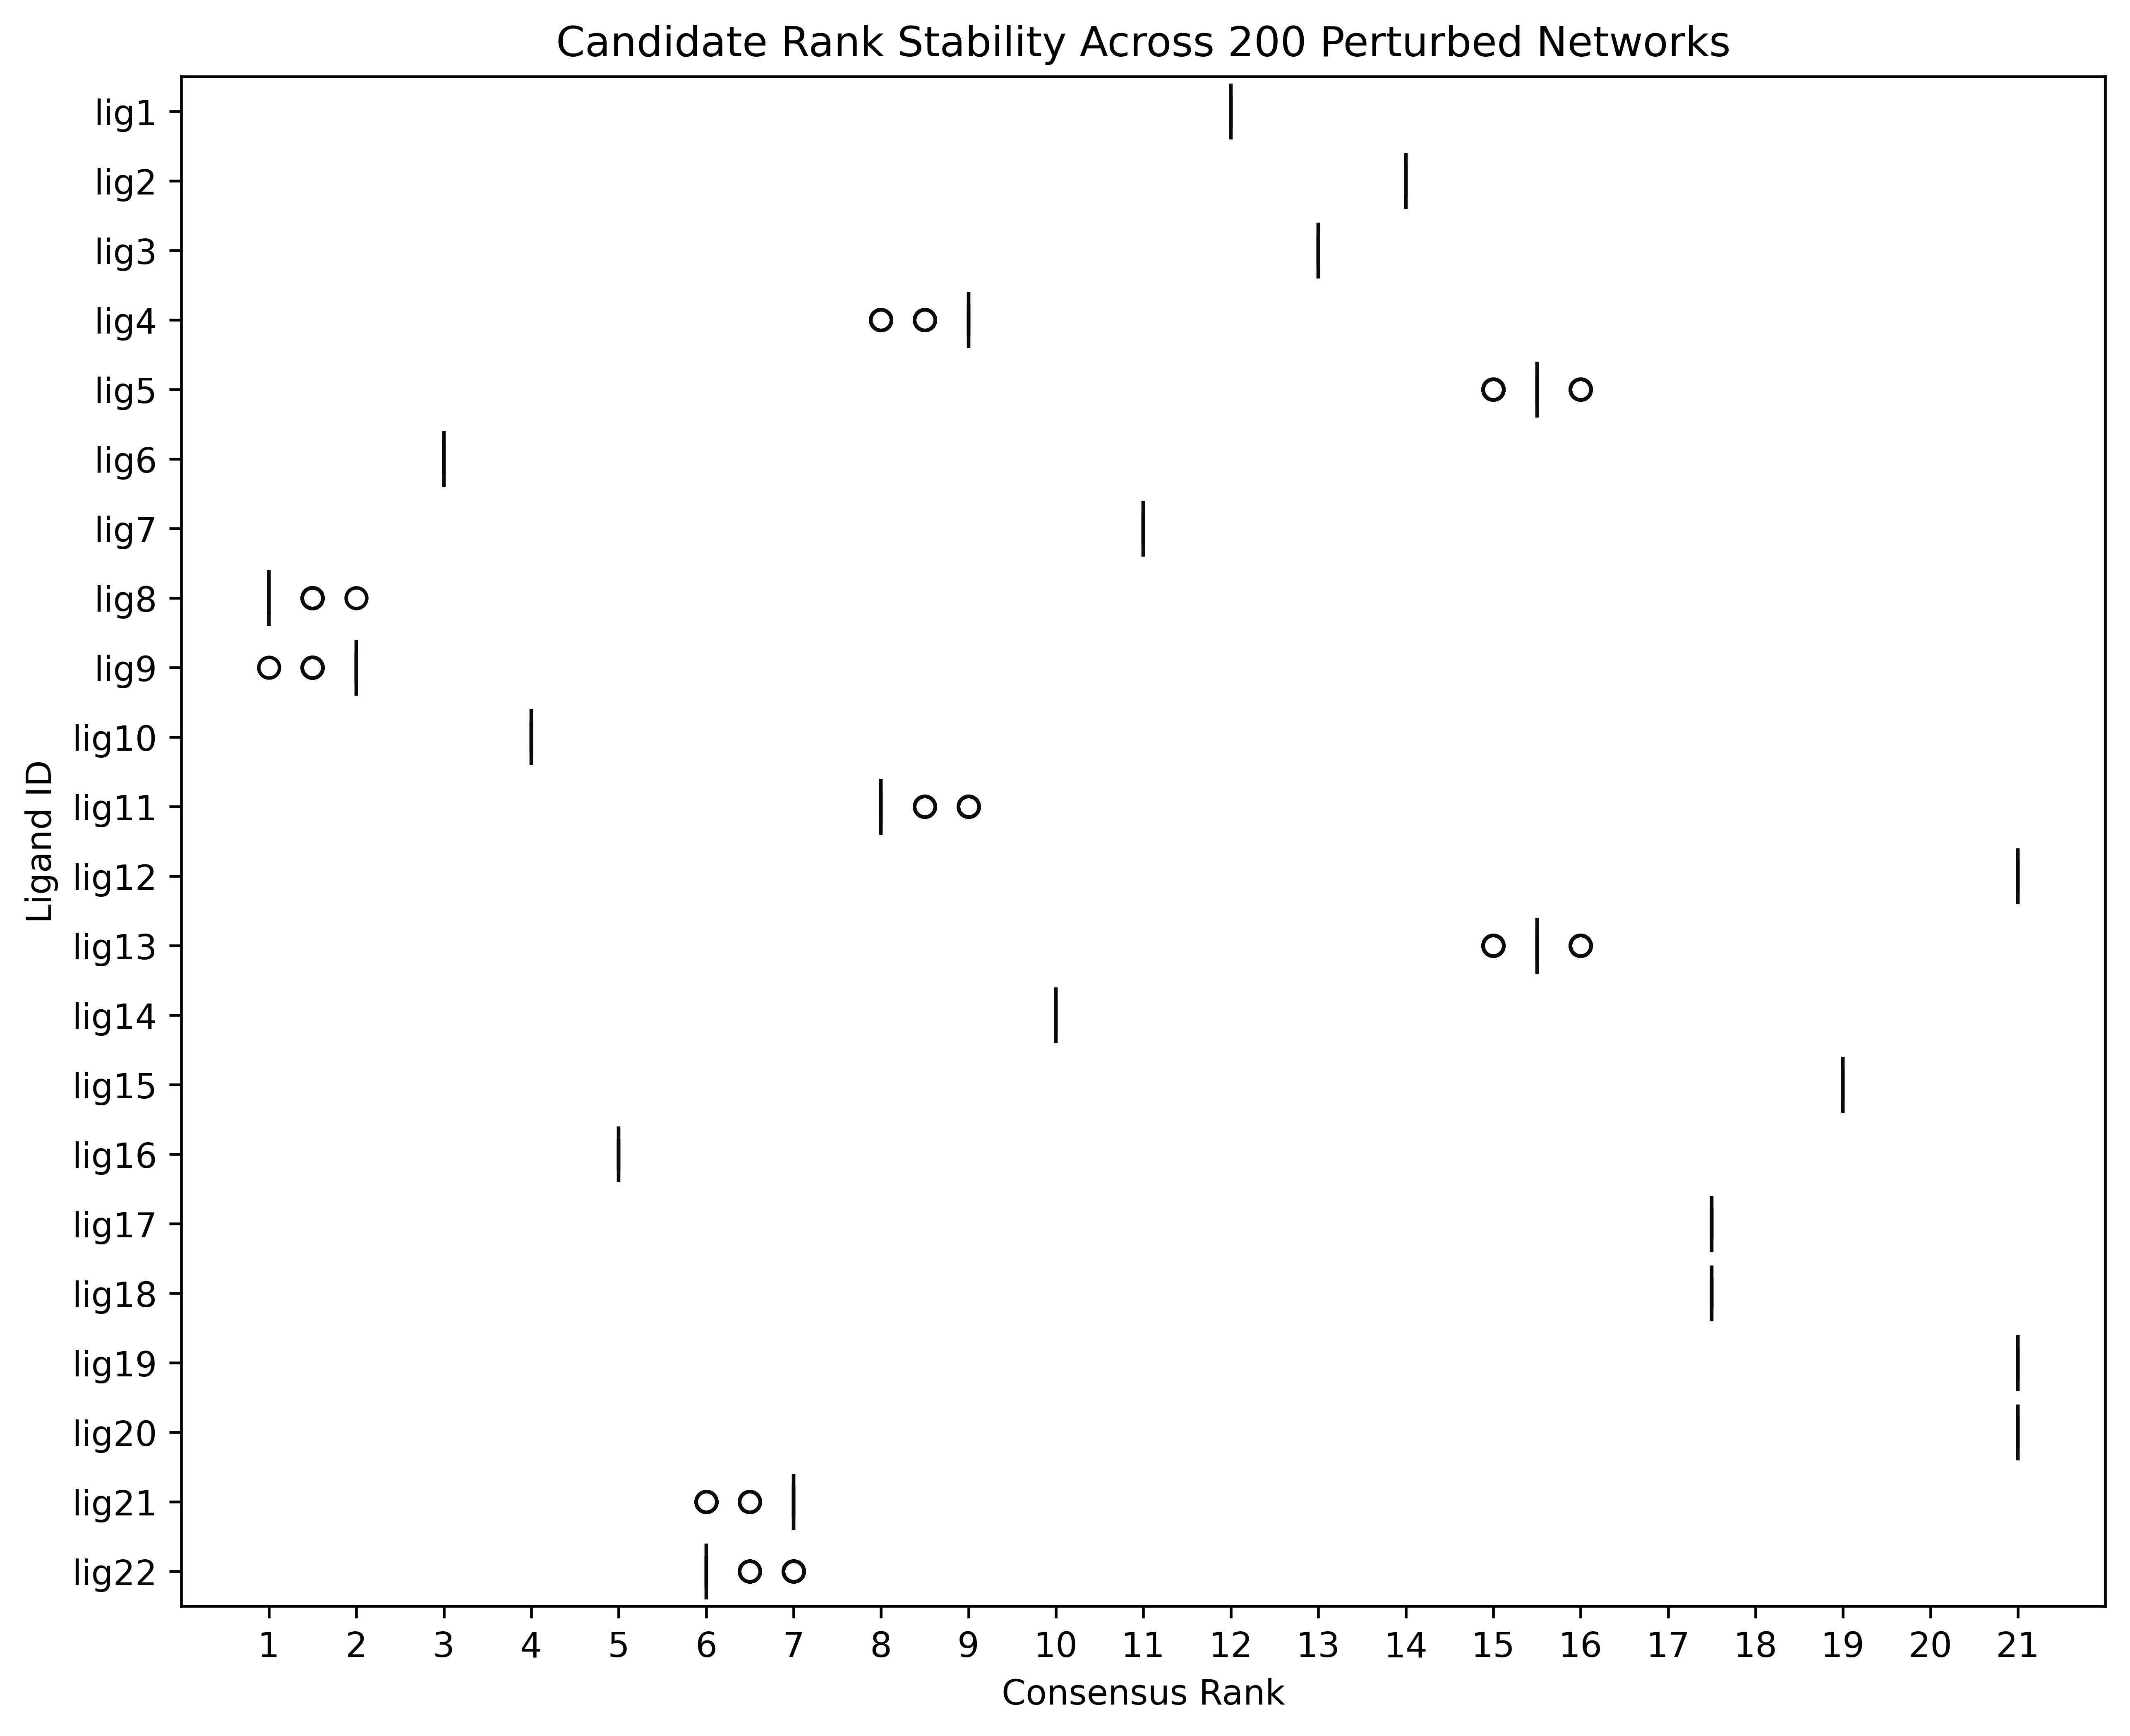

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import set_matplotlib_formats

# 1. Force Colab to render the inline plot in high-definition (Retina)
set_matplotlib_formats('retina')

rank_df = df_results.rank(axis=1, ascending=True)
sorted_ligands = sorted(rank_df.columns, key=lambda x: int(x.replace("lig", "")))

# 2. Set dpi=300 for publication quality
plt.figure(figsize=(10, 8), dpi=300)
sns.boxplot(data=rank_df[sorted_ligands], orient="h", palette="mako")

plt.title("Candidate Rank Stability Across 200 Perturbed Networks")
plt.xlabel("Consensus Rank")
plt.ylabel("Ligand ID")
plt.xticks(range(1, 22))

# 3. Save directly to Colab environment in high resolution
plt.savefig("network_stability_boxplot_300dpi.png", dpi=300, bbox_inches="tight")

plt.show()

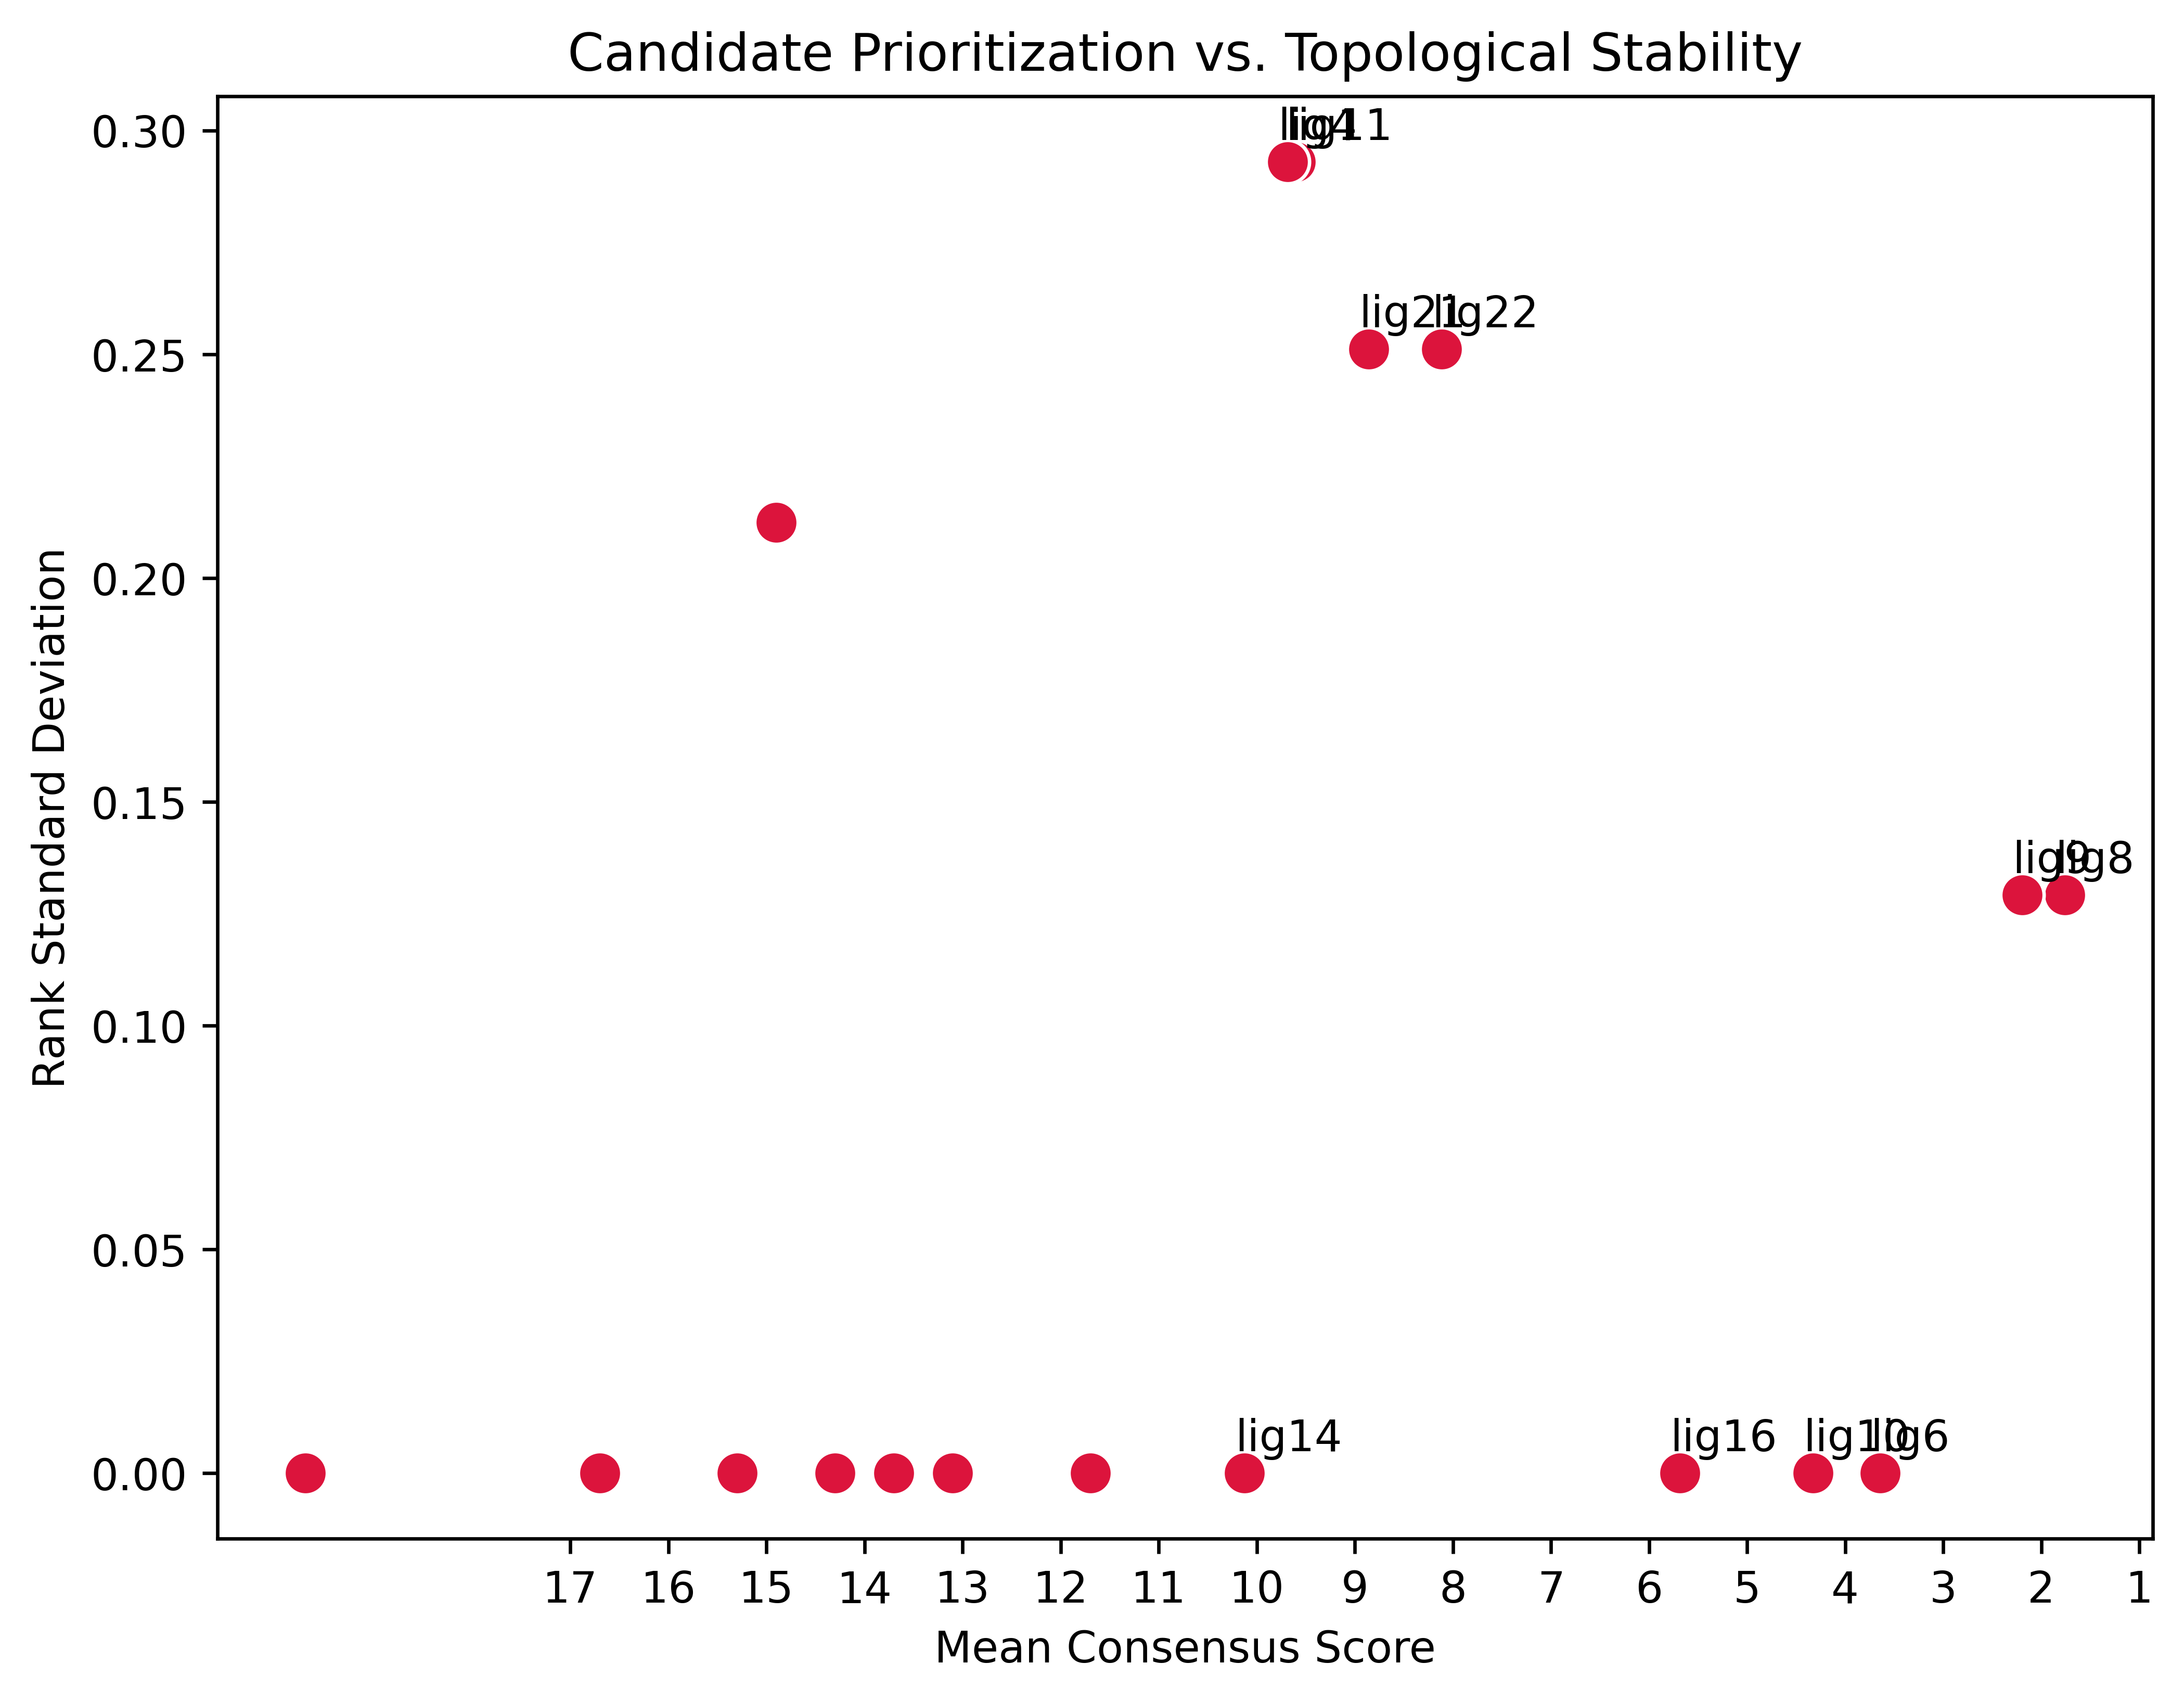

In [ ]:
# 1. Force Colab to render the inline plot in high-definition (Retina)
set_matplotlib_formats('retina')

plt.figure(figsize=(8, 6), dpi=300)
sns.scatterplot(x=summary["mean_score"], y=summary["rank_std"], s=100, color="crimson")

# Annotate the top 10 points
for i, txt in enumerate(summary.index[:10]):
    plt.annotate(txt, (summary["mean_score"].iloc[i] + 0.1, summary["rank_std"].iloc[i] + 0.005))

plt.title("Candidate Prioritization vs. Topological Stability")
plt.xlabel("Mean Consensus Score")
plt.ylabel("Rank Standard Deviation")
plt.gca().invert_xaxis() # Put better scores on the right

# Set x-axis ticks to whole numbers from 1 to 20
plt.xticks(range(1, 18))
plt.show()

# Export to Gephi

In [ ]:
nx.write_gexf(G, "Network-Based-FINAL0304.gexf")

## Miscellaneous: Community Detection

In [ ]:
!pip install igraph
!pip install leidenalg

import igraph as ig
import leidenalg as la

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 36.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 29.4 MB/s eta 0:00:00


In [ ]:
# ==========================================
# 7. LEIDEN COMMUNITY DETECTION (SCAFFOLDS)
# ==========================================
# Isolate the ligand-only sub-network to prevent receptor gravitational pull
ligand_nodes = [n for n in G.nodes() if str(n).startswith("lig")]
G_ligands = G.subgraph(ligand_nodes).copy()

# Remove any edges that are not purely chemical similarity (e.g., penalty edges)
invalid_edges = [(u, v) for u, v, d in G_ligands.edges(data=True) if d.get('edge_type') != 'chemical_similarity']
G_ligands.remove_edges_from(invalid_edges)

# Convert NetworkX subgraph to igraph format
ig_graph = ig.Graph.from_networkx(G_ligands)

# Run Leiden algorithm using Tanimoto similarity weights
partition = la.find_partition(ig_graph, la.ModularityVertexPartition, weights='weight')

# Map the resulting Modularity Classes back to the main multi-layered graph (G)
leiden_dict = {ig_graph.vs[i]['_nx_name']: int(partition.membership[i]) for i in range(ig_graph.vcount())}
nx.set_node_attributes(G, leiden_dict, "leiden_community")

# Note: The receptors (4KIK, 4L7F) will not have a 'leiden_community' attribute, which is mathematically correct.

In [ ]:
import pandas as pd

# Extract ligand nodes and their assigned Leiden community
community_data = []
for n, data in G.nodes(data=True):
    if str(n).startswith("lig"):
        community_data.append({
            "Ligand": n,
            "Leiden_Community": data.get("leiden_community", "None")
        })

# Create a DataFrame and sort it by community
df_communities = pd.DataFrame(community_data)
df_communities = df_communities.sort_values(by=["Leiden_Community", "Ligand"])

# Print the grouped results
print(df_communities.to_string(index=False))

# Optional: Save this table to include in your Chapter IV Appendix
df_communities.to_csv("leiden_communities.csv", index=False)

Ligand  Leiden_Community
  lig1                 0
 lig10                 0
 lig14                 0
  lig2                 0
  lig3                 0
  lig6                 0
  lig7                 0
  lig8                 0
 lig11                 1
 lig13                 1
 lig15                 1
  lig5                 1
  lig9                 1
 lig21                 2
 lig22                 2
  lig4                 2
 lig17                 3
 lig18                 3
 lig16                 4
 lig12                 5
 lig19                 6
 lig20                 7


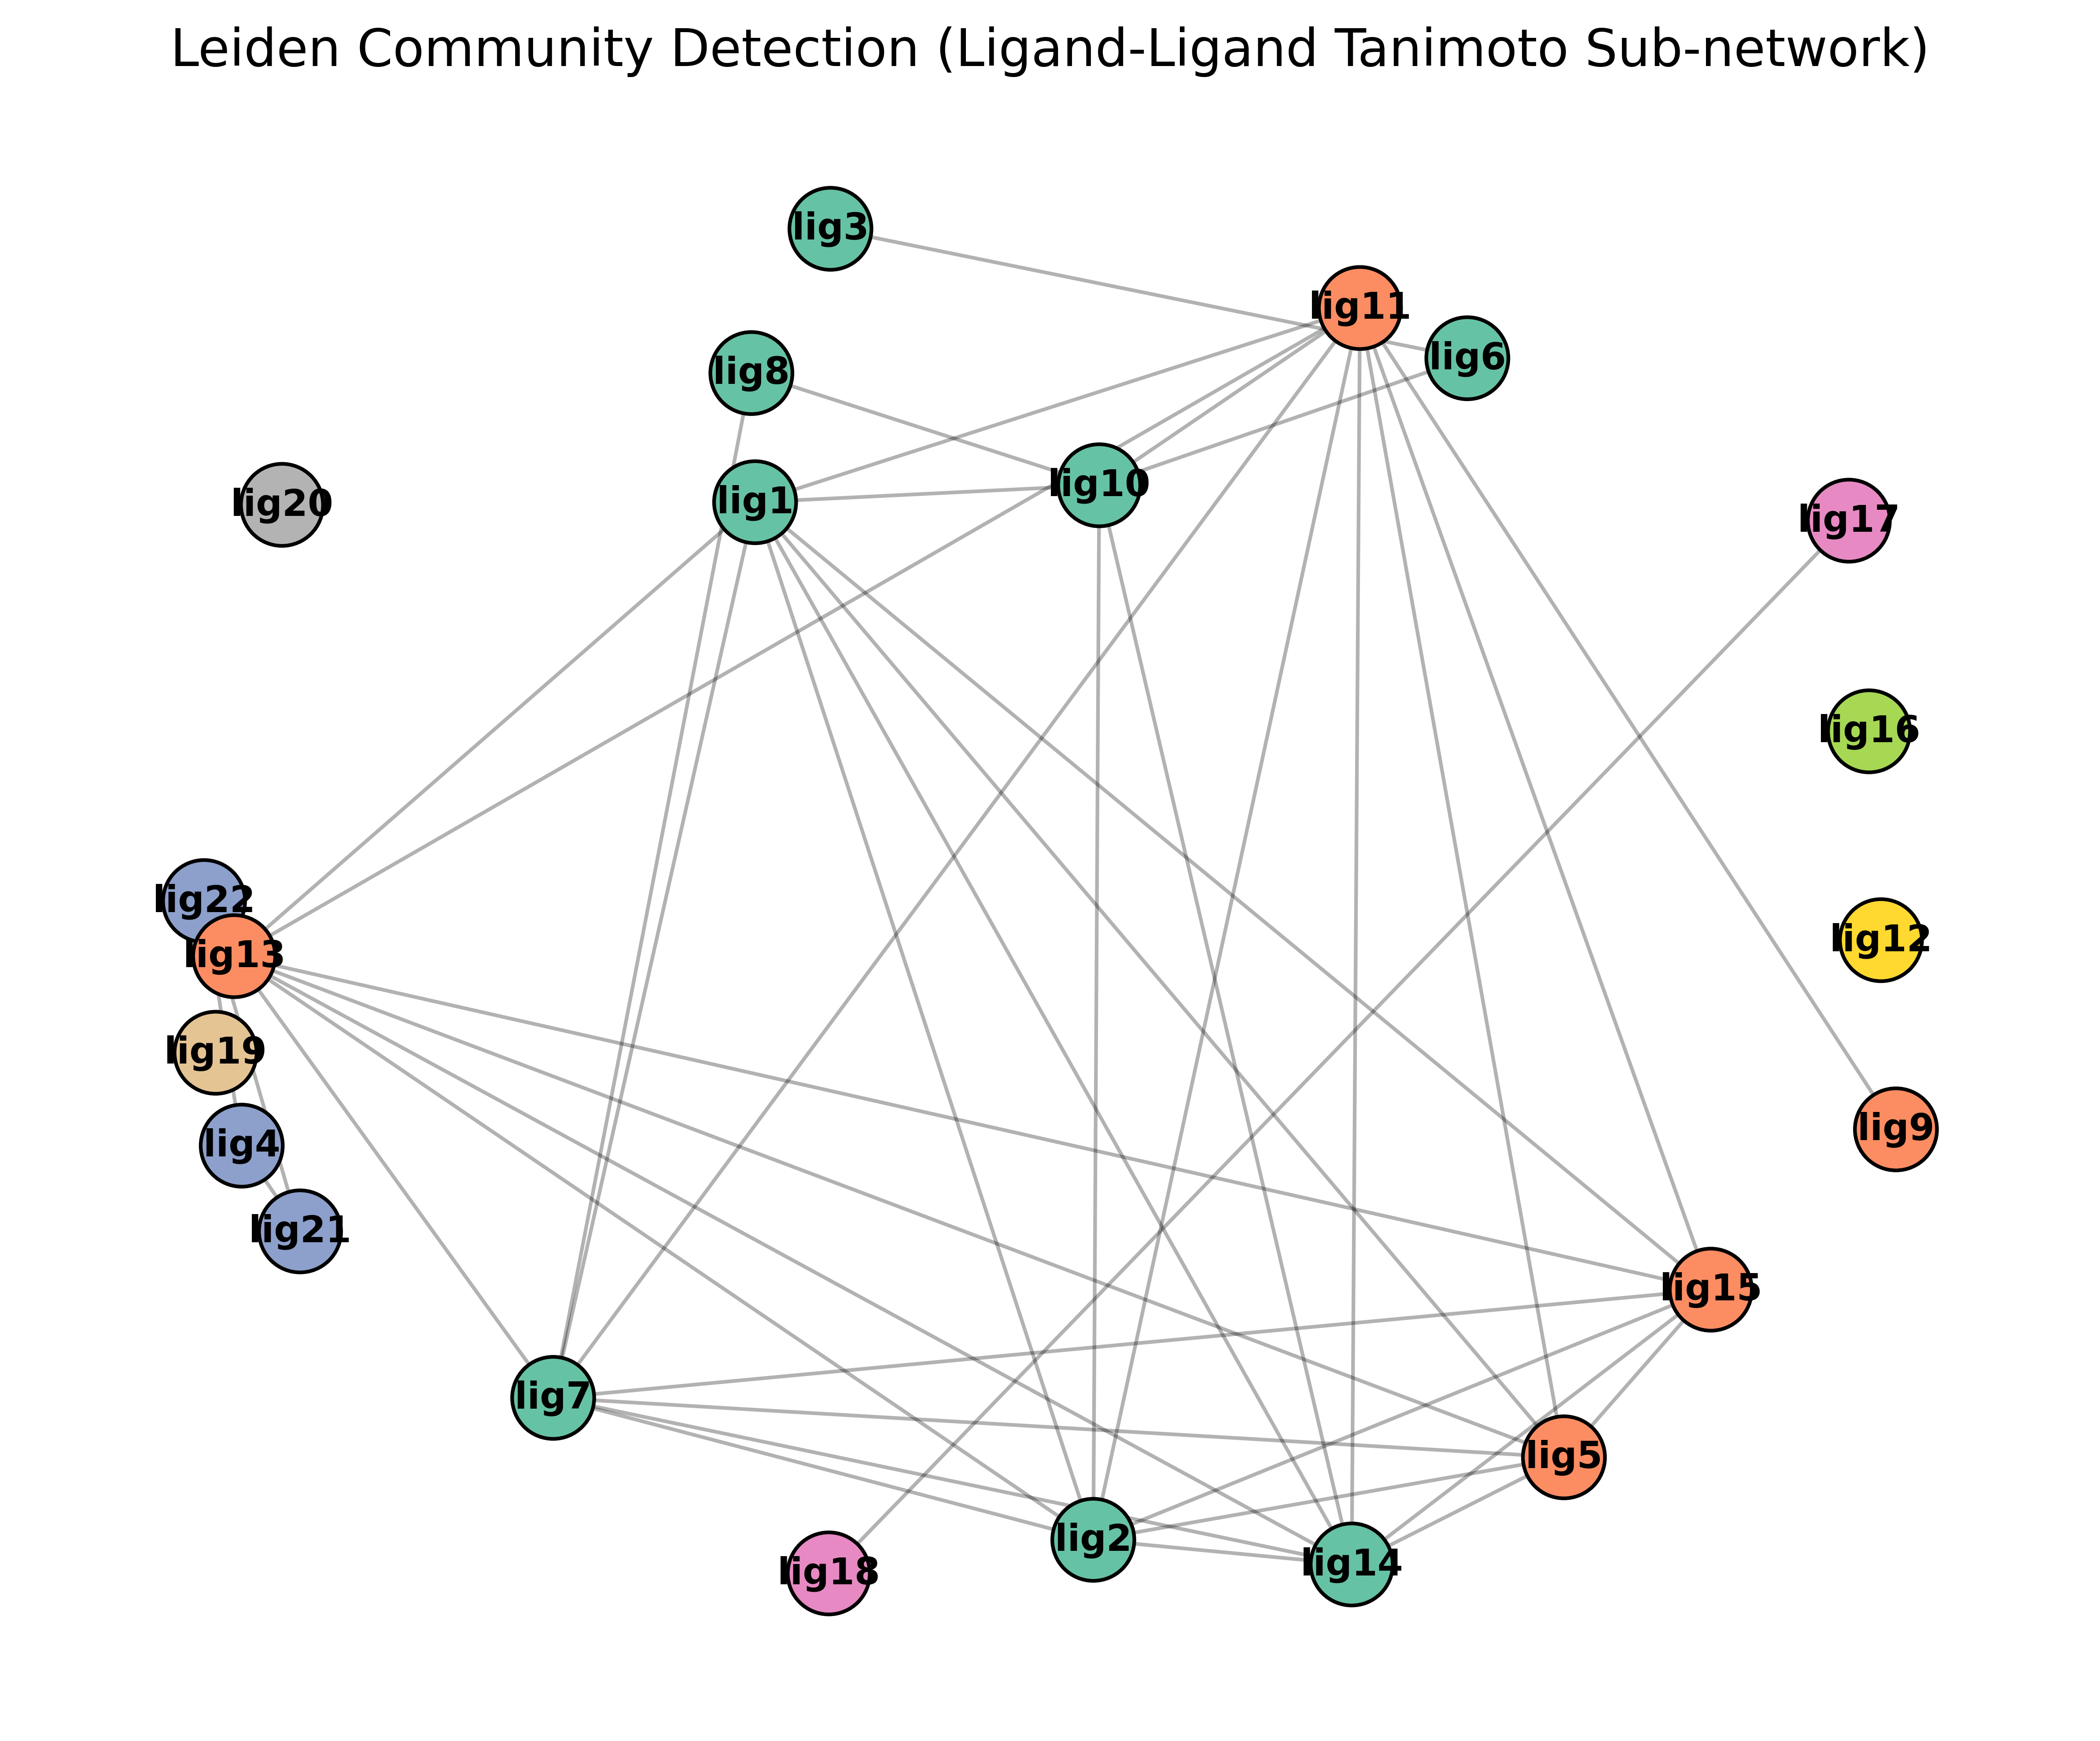

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx

# Isolate just the ligands for a clean visual (ignoring the massive receptor edges)
ligand_nodes = [n for n in G.nodes() if str(n).startswith("lig")]
H = G.subgraph(ligand_nodes)

# Extract community integers to use as a color map
# (Fallback to 0 if something went wrong)
color_map = [H.nodes[n].get("leiden_community", 0) for n in H.nodes()]

# Draw the network
plt.figure(figsize=(10, 8), dpi=300)
pos = nx.spring_layout(H, seed=42) # Seed for reproducible layout

nx.draw_networkx_nodes(H, pos, node_size=500, node_color=color_map, cmap=plt.cm.Set2, edgecolors="black")
nx.draw_networkx_edges(H, pos, alpha=0.3)
nx.draw_networkx_labels(H, pos, font_size=10, font_weight="bold")

plt.title("Leiden Community Detection (Ligand-Ligand Tanimoto Sub-network)", fontsize=14)
plt.axis("off")
plt.show()

# Improvements: Additionals

In [ ]:
from scipy.stats import spearmanr

In [ ]:
# =============================================================================
# CELL A — FIXED compute_consensus_scores (same names as your inline cell)
# =============================================================================
def _eigen_safe(G):
    """Iterative eigenvector centrality, falling back to the numpy solver
    on the near-bipartite graphs where power iteration fails to converge."""
    try:
        return nx.eigenvector_centrality(G, weight="weight", max_iter=2000, tol=1e-6)
    except nx.PowerIterationFailedConvergence:
        return nx.eigenvector_centrality_numpy(G, weight="weight")

def compute_consensus_scores(G):
    for u, v, d in G.edges(data=True):
        d["distance"] = 1 / (d["weight"] + 1e-6)

    lig_nodes = [n for n in G.nodes() if str(n).startswith("lig")]

    degree      = dict(G.degree(weight="weight"))
    betweenness = nx.betweenness_centrality(G, weight="distance")
    closeness   = nx.closeness_centrality(G, distance="distance")
    eigenvector = nx.eigenvector_centrality(G, weight="weight", max_iter=2000)
    pagerank    = nx.pagerank(G, weight="weight")

    df = pd.DataFrame({
        "node":          lig_nodes,
        "weighteddegree":[degree.get(n, 0)      for n in lig_nodes],
        "betweenness":   [betweenness.get(n, 0) for n in lig_nodes],
        "closeness":     [closeness.get(n, 0)   for n in lig_nodes],
        "eigenvector":   [eigenvector.get(n, 0) for n in lig_nodes],
        "pagerank":      [pagerank.get(n, 0)    for n in lig_nodes],
    })

    cols = ["weighteddegree", "betweenness", "closeness", "eigenvector", "pagerank"]
    df[cols] = MinMaxScaler().fit_transform(df[cols])
    for col in cols:
        df[col + "_rank"] = df[col].rank(ascending=False, method="average")

    rank_cols = [c for c in df.columns if "_rank" in c]
    df["consensus_score"] = df[rank_cols].mean(axis=1)
    df["final_rank"] = df["consensus_score"].rank(method="min")
    df_sorted = df.sort_values("consensus_score").reset_index(drop=True)
    return df_sorted

# Baseline ranking (reproduces your df_sorted)
df_sorted = compute_consensus_scores(G)
print(df_sorted[["node", "consensus_score", "final_rank"]].head(10).to_string(index=False))

 node  consensus_score  final_rank
 lig8              1.6         1.0
 lig9              2.2         2.0
 lig6              3.6         3.0
lig10              4.4         4.0
lig16              5.7         5.0
lig22              8.1         6.0
lig21              8.9         7.0
lig11              9.6         8.0
 lig4              9.7         9.0
lig14             10.2        10.0


In [ ]:
# =============================================================================
# CELL B — Parameterized graph builder (same construction logic as your cell)
# =============================================================================
def build_graph(layer_weights):
    min_admet = admet_df["admet_norm"].min()

    # Layer 1: docking x ADMET  (raw cols already present after your construction cell)
    dock_edges_b = dock_edges.copy()
    dock_edges_b["admet_weight"] = dock_edges_b["source"].map(admet_df["admet_norm"]).fillna(min_admet)
    dock_edges_b["weight"] = (
        dock_edges_b["docking_weight"] * dock_edges_b["admet_weight"] * layer_weights["docking_admet"]
    )
    dock_edges_b["layer"] = "docking_admet"
    dock_edges_b["edge_type"] = "binding"

    # Layer 2: chemical similarity
    tanimoto_edges_b = tanimoto_edges.copy()
    tanimoto_edges_b["weight"] = tanimoto_edges_b["similarity_weight"] * layer_weights["similarity"]
    tanimoto_edges_b["layer"] = "similarity"
    tanimoto_edges_b["edge_type"] = "chemical_similarity"

    G = nx.from_pandas_edgelist(
        pd.concat([dock_edges_b, tanimoto_edges_b]),
        source="source", target="target", edge_attr=True, create_using=nx.Graph()
    )

    all_nodes = [f"lig{i}" for i in range(1, 23)] + ["4KIK", "4L7F"]
    G.add_nodes_from(all_nodes)

    lig_nodes = [n for n in G.nodes() if str(n).startswith("lig")]
    for lig in lig_nodes:
        has_docking = any(n in ["4KIK", "4L7F"] for n in G.neighbors(lig))
        if not has_docking:
            for prot in ["4KIK", "4L7F"]:
                G.add_edge(lig, prot, weight=1e-6, layer="docking_admet", edge_type="binding")
            for u, v, d in G.edges(lig, data=True):
                d["weight"] *= 0.05

    nx.set_node_attributes(G, "metabolite", "type")
    nx.set_node_attributes(G, {n: "protein" for n in ["4KIK", "4L7F"]}, "type")
    return G

In [ ]:
# =============================================================================
# CELL C — CIRCULARITY CONTROL (Methodology 3.4.4)
# -----------------------------------------------------------------------------
# Naive docking x ADMET ranking vs network consensus ranking (df_sorted).
# =============================================================================
best_dock = dock_edges.groupby("source")["docking_weight"].max()

naive = pd.DataFrame({"node": [f"lig{i}" for i in range(1, 23)]})
naive["dock_best"]   = naive["node"].map(best_dock).fillna(best_dock.min())
naive["admet_norm"]  = naive["node"].map(admet_df["admet_norm"]).fillna(admet_df["admet_norm"].min())
naive["naive_score"] = naive["dock_best"] * naive["admet_norm"]
naive["naive_rank"]  = naive["naive_score"].rank(ascending=False, method="min")  # 1 = best

merged = naive.merge(df_sorted[["node", "final_rank"]], on="node")  # both: 1 = best
rho, pval = spearmanr(merged["naive_rank"], merged["final_rank"])

print("\n=== CIRCULARITY CONTROL ===")
print(f"Spearman rho (naive docking×ADMET vs network consensus): {rho:.4f} (p={pval:.4g})")
print("~>0.95 => network mostly re-encodes inputs;  ~0.6–0.85 => network adds signal.")
print(merged.sort_values("final_rank")[["node", "naive_rank", "final_rank"]].head(10).to_string(index=False))



=== CIRCULARITY CONTROL ===
Spearman rho (naive docking×ADMET vs network consensus): 0.2007 (p=0.3704)
~>0.95 => network mostly re-encodes inputs;  ~0.6–0.85 => network adds signal.
 node  naive_rank  final_rank
 lig8         2.0         1.0
 lig9         1.0         2.0
 lig6         8.0         3.0
lig10        18.0         4.0
lig16         3.0         5.0
lig22        15.0         6.0
lig21        16.0         7.0
lig11        20.0         8.0
 lig4        19.0         9.0
lig14         4.0        10.0


In [ ]:
# =============================================================================
# CELL D — LAYER-WEIGHT SENSITIVITY (Methodology 3.4.4)
# -----------------------------------------------------------------------------
# Re-runs prioritization across functional/structural ratios; Spearman vs baseline.
# =============================================================================
grid = [(0.95, 0.05), (0.90, 0.10), (0.80, 0.20), (0.70, 0.30)]
baseline_rank = df_sorted.set_index("node")["final_rank"]

print("\n=== LAYER-WEIGHT SENSITIVITY ===")
sens_rows = []
for func_w, sim_w in grid:
    G_lw = build_graph({"docking_admet": func_w, "similarity": sim_w})
    cons_lw = compute_consensus_scores(G_lw).set_index("node")["final_rank"]
    aligned = pd.concat([baseline_rank, cons_lw], axis=1, keys=["base", "alt"]).dropna()
    r, _ = spearmanr(aligned["base"], aligned["alt"])
    top5 = cons_lw.sort_values().head(5).index.tolist()
    sens_rows.append({"layer_ratio": f"{func_w}/{sim_w}",
                      "spearman_vs_baseline": round(r, 4),
                      "top5": ", ".join(top5)})
sens_df = pd.DataFrame(sens_rows)
print(sens_df.to_string(index=False))



=== LAYER-WEIGHT SENSITIVITY ===
layer_ratio  spearman_vs_baseline                           top5
  0.95/0.05                1.0000 lig8, lig9, lig6, lig10, lig16
    0.9/0.1                0.9997 lig8, lig9, lig6, lig10, lig16
    0.8/0.2                0.9949 lig8, lig9, lig10, lig6, lig22
    0.7/0.3                0.9907 lig8, lig10, lig9, lig6, lig22


In [ ]:
# =============================================================================
# CELL E — NULL MODELS + FDR (Methodology 3.4.5)
# -----------------------------------------------------------------------------
# Extends Erdos–Renyi cell with a degree-preserving (configuration) null, empirical two-tailed p-values, 95% null intervals, and Benjamini–Hochberg FDR.
# Tests the structurally meaningful metrics (avg_degree/density are matched by construction).
# =============================================================================
real_metrics = get_topology(G)
metrics_tested = ["clustering", "diameter", "path_length"]

def degree_preserving_null(graph, seed):
    R = graph.copy()
    m = R.number_of_edges()
    try:
        nx.double_edge_swap(R, nswap=10 * m, max_tries=100 * m, seed=seed)
    except (nx.NetworkXError, nx.NetworkXAlgorithmError):
        pass  # degree sequence still preserved even if not all swaps complete
    return R

def empirical_two_tailed_p(observed, null_vals):
    null = np.asarray(null_vals, dtype=float)
    null = null[~np.isnan(null)]
    if len(null) == 0:
        return np.nan
    center = null.mean()
    extreme = np.abs(null - center) >= np.abs(observed - center)
    return min((extreme.sum() + 1) / (len(null) + 1), 1.0)

def compare_against_null(real_metrics, null_metrics_list, label):
    null_df = pd.DataFrame(null_metrics_list)
    rows = []
    for met in metrics_tested:
        obs, nul = real_metrics[met], null_df[met].values
        rows.append({
            "null_model": label, "metric": met,
            "Real_Network": round(obs, 4),
            "Random_Mean": round(np.nanmean(nul), 4),
            "null_CI_2.5": round(np.nanpercentile(nul, 2.5), 4),
            "null_CI_97.5": round(np.nanpercentile(nul, 97.5), 4),
            "p_value": empirical_two_tailed_p(obs, nul),
        })
    res = pd.DataFrame(rows)
    res["p_adj_BH"] = multipletests(res["p_value"], method="fdr_bh")[1]
    res["significant"] = res["p_adj_BH"] < 0.05
    return res

# (a) Erdos–Renyi  (same generation as your existing cell)
er_metrics = [get_topology(nx.erdos_renyi_graph(n=n_nodes, p=p_density, seed=s)) for s in range(1000)]
er_res = compare_against_null(real_metrics, er_metrics, "Erdos-Renyi")

# (b) Degree-preserving / configuration
cfg_metrics = [get_topology(degree_preserving_null(G, s)) for s in range(1000)]
cfg_res = compare_against_null(real_metrics, cfg_metrics, "Degree-preserving")

null_summary = pd.concat([er_res, cfg_res], ignore_index=True)
print("\n=== NULL MODEL COMPARISON (FDR-corrected) ===")
print(null_summary.to_string(index=False))
null_summary.to_csv("null_model_comparison.csv", index=False)
print("Saved -> null_model_comparison.csv")


=== NULL MODEL COMPARISON (FDR-corrected) ===
       null_model      metric  Real_Network  Random_Mean  null_CI_2.5  null_CI_97.5  p_value  p_adj_BH  significant
      Erdos-Renyi  clustering        0.6045       0.3039       0.2181        0.3887 0.000999  0.001499         True
      Erdos-Renyi    diameter        2.0000       3.0990       3.0000        4.0000 0.000999  0.001499         True
      Erdos-Renyi path_length        1.6957       1.7750       1.6702        1.9167 0.227772  0.227772        False
Degree-preserving  clustering        0.6045       0.7815       0.7390        0.8110 0.001998  0.005994         True
Degree-preserving    diameter        2.0000       2.9010       2.0000        3.0000 0.099900  0.149850        False
Degree-preserving path_length        1.6957       1.7041       1.6957        1.7355 0.205794  0.205794        False
Saved -> null_model_comparison.csv


In [ ]:
# =============================================================================
# CELL F — (OPTIONAL) EDGE-WEIGHT SHUFFLE NULL on the consensus top-5
# -----------------------------------------------------------------------------
# Holds topology fixed, permutes weights, recomputes consensus; reports how often
# the real top-5 is recovered by chance.
# =============================================================================
from sklearn.preprocessing import MinMaxScaler

def consensus_numpy(G):
    """Self-contained consensus scorer using the numpy eigenvector solver
    (no power iteration -> no convergence failures on shuffled graphs)."""
    for u, v, d in G.edges(data=True):
        d["distance"] = 1 / (d["weight"] + 1e-6)
    lig_nodes = [n for n in G.nodes() if str(n).startswith("lig")]

    degree      = dict(G.degree(weight="weight"))
    betweenness = nx.betweenness_centrality(G, weight="distance")
    closeness   = nx.closeness_centrality(G, distance="distance")
    eigenvector = nx.eigenvector_centrality_numpy(G, weight="weight")   # direct solver
    pagerank    = nx.pagerank(G, weight="weight")

    df = pd.DataFrame({
        "node":          lig_nodes,
        "weighteddegree":[degree.get(n, 0)      for n in lig_nodes],
        "betweenness":   [betweenness.get(n, 0) for n in lig_nodes],
        "closeness":     [closeness.get(n, 0)   for n in lig_nodes],
        "eigenvector":   [eigenvector.get(n, 0) for n in lig_nodes],
        "pagerank":      [pagerank.get(n, 0)    for n in lig_nodes],
    })
    cols = ["weighteddegree", "betweenness", "closeness", "eigenvector", "pagerank"]
    df[cols] = MinMaxScaler().fit_transform(df[cols])
    for col in cols:
        df[col + "_rank"] = df[col].rank(ascending=False, method="average")
    rank_cols = [c for c in df.columns if "_rank" in c]
    df["consensus_score"] = df[rank_cols].mean(axis=1)
    return df.sort_values("consensus_score").reset_index(drop=True)


# --- Edge-weight shuffle null ---
real_top5 = df_sorted.head(5)["node"].tolist()
rng = np.random.default_rng(42)
edges = list(G.edges(data=True))
weights = np.array([d["weight"] for _, _, d in edges])

overlaps = []
for _ in range(1000):
    Gs = G.copy()
    for (u, v, _), w in zip(edges, rng.permutation(weights)):
        Gs[u][v]["weight"] = w
    topk = consensus_numpy(Gs).head(5)["node"].tolist()
    overlaps.append(len(set(real_top5) & set(topk)) / 5)
overlaps = np.array(overlaps)

print("=== EDGE-WEIGHT SHUFFLE NULL (top-5 recovery) ===")
print(f"Real top-5: {real_top5}")
print(f"Mean random overlap: {overlaps.mean():.3f} "
      f"(95% null interval {np.percentile(overlaps,2.5):.3f}-{np.percentile(overlaps,97.5):.3f})")

=== EDGE-WEIGHT SHUFFLE NULL (top-5 recovery) ===
Real top-5: ['lig8', 'lig9', 'lig6', 'lig10', 'lig16']
Mean random overlap: 0.159 (95% null interval 0.000-0.400)


# Figures

In [ ]:
# =============================================================================
# PHASE 3 VALIDATION FIGURES  —  aligned to your notebook variables
# =============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

sns.set_style("whitegrid")

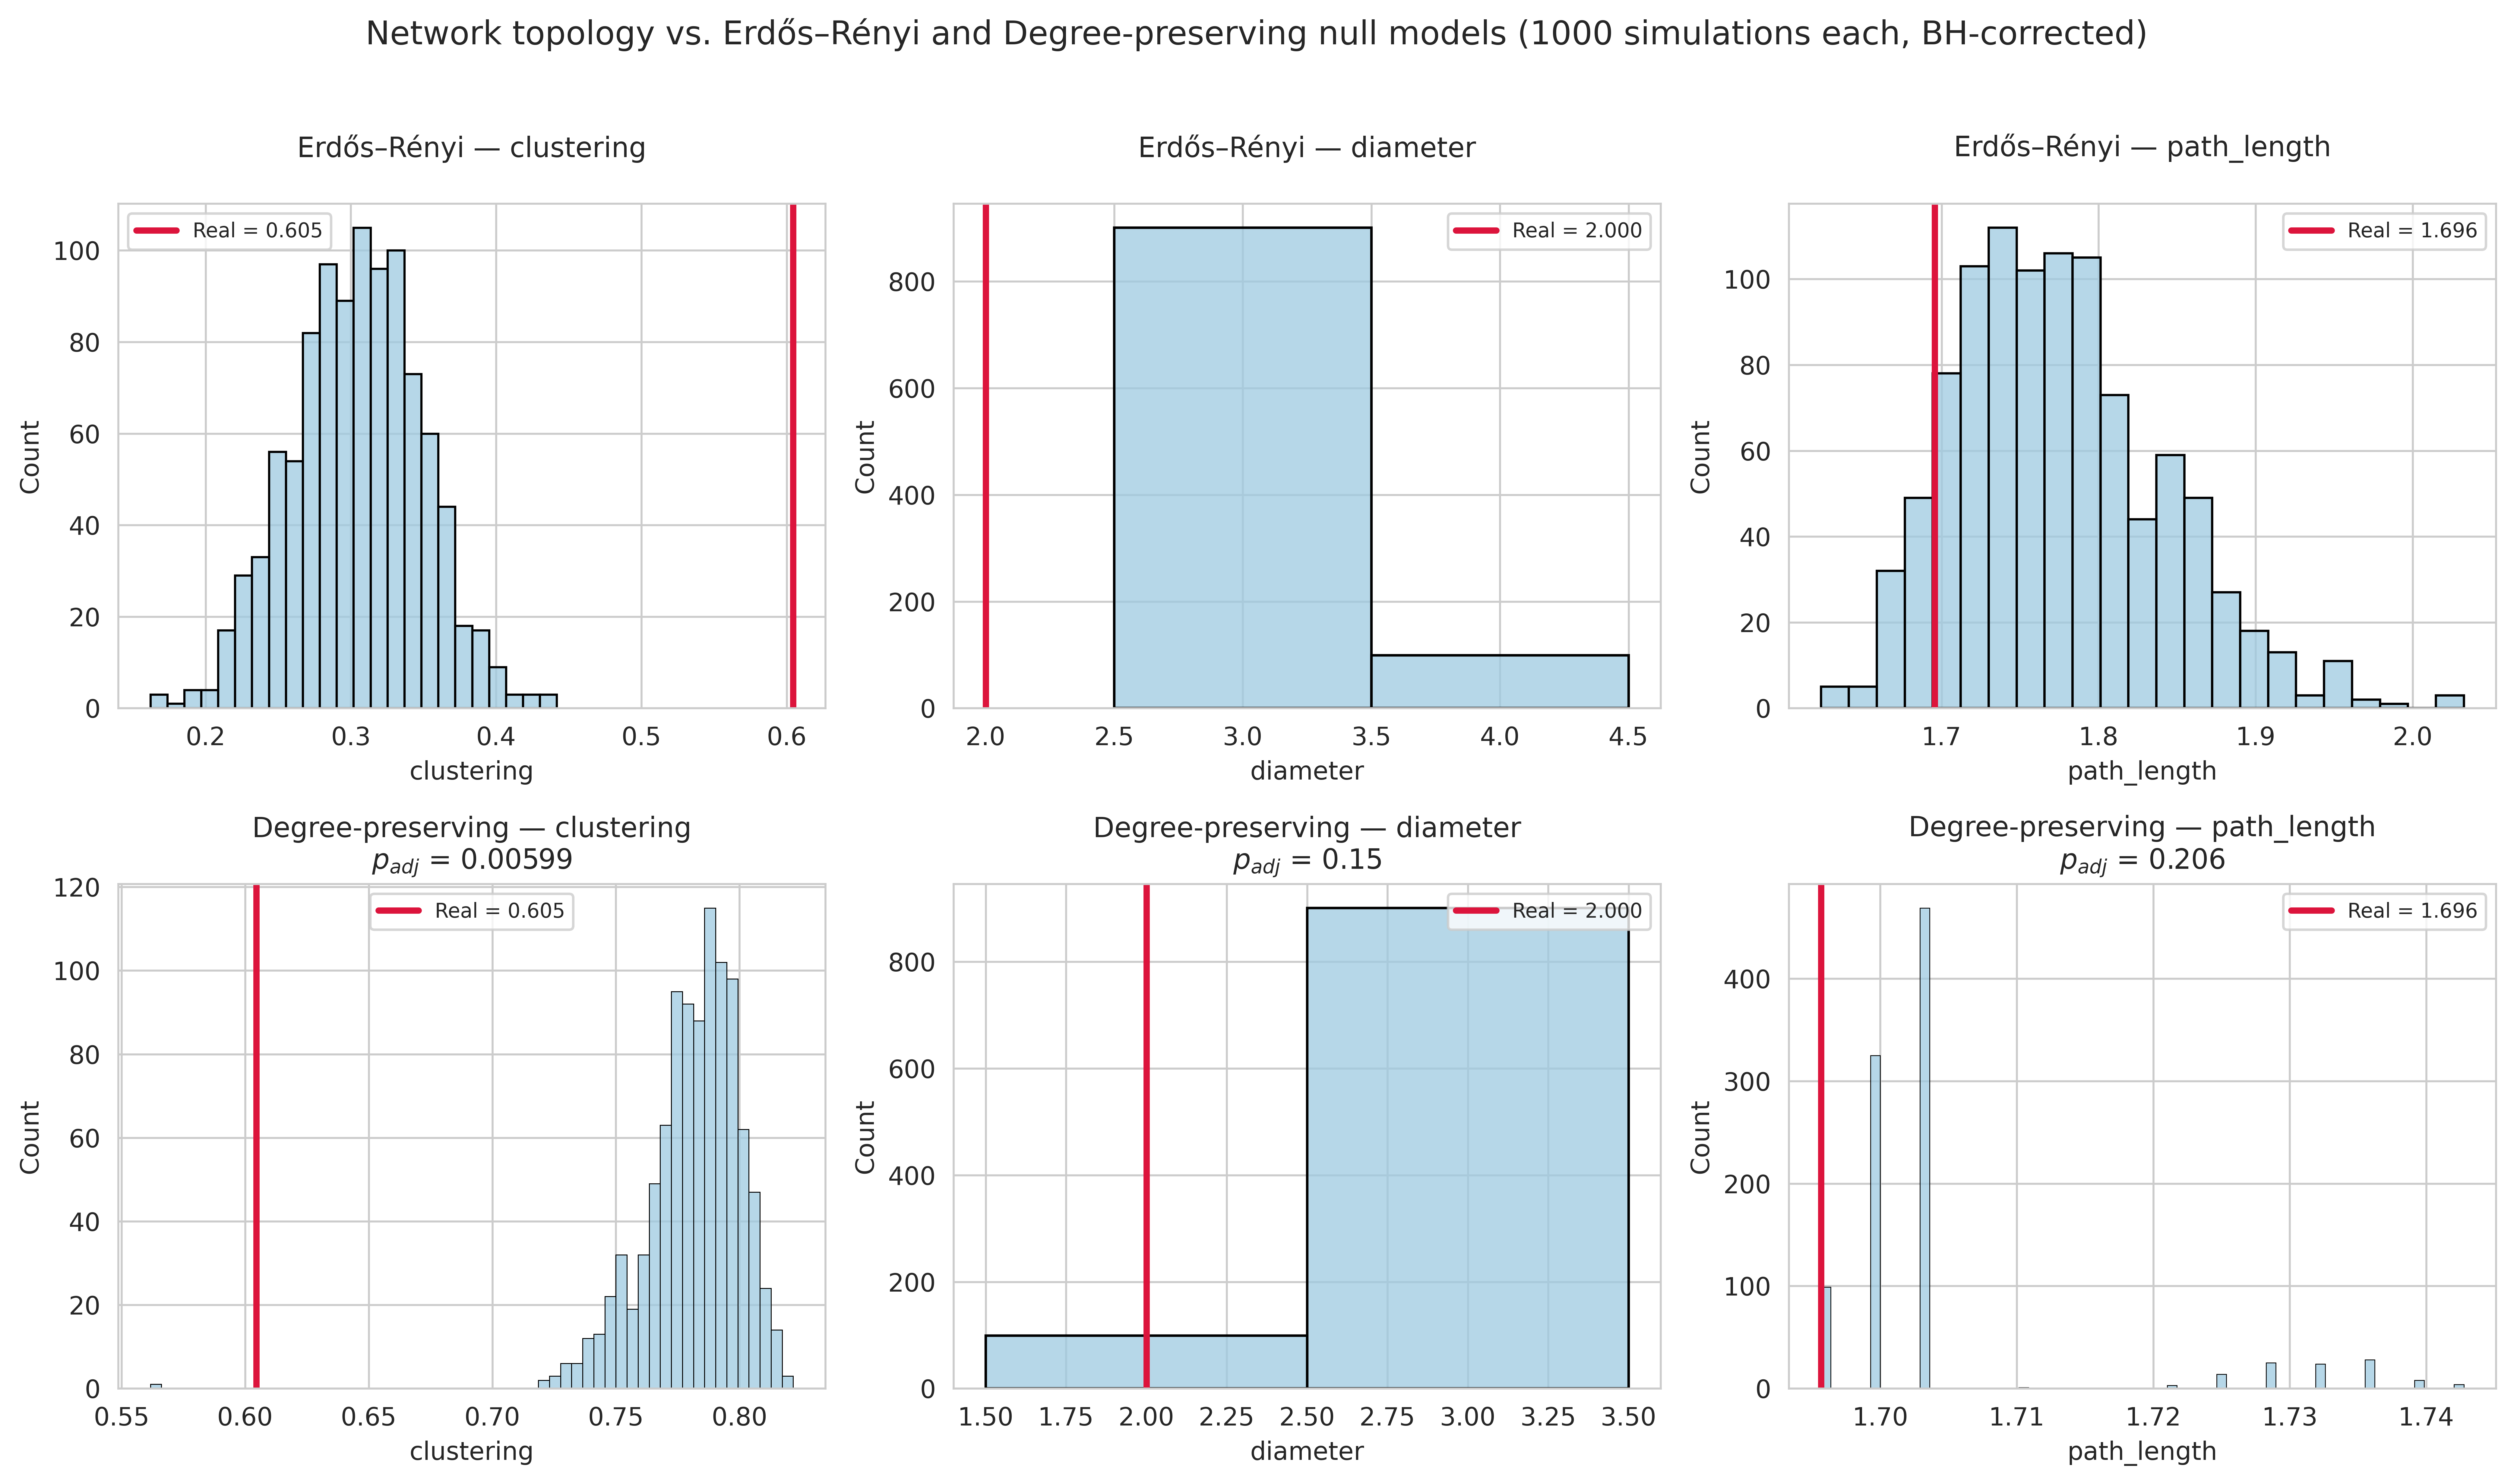

In [ ]:
# =============================================================================
# FIGURE 1 — Null model distributions
# Real metric (red line) against ER and degree-preserving null distributions.
# =============================================================================
er_df  = pd.DataFrame(er_metrics)
cfg_df = pd.DataFrame(cfg_metrics)
metrics = ["clustering", "diameter", "path_length"]
nulls = [(er_df, "Erdős–Rényi"), (cfg_df, "Degree-preserving")]

fig, axes = plt.subplots(2, 3, figsize=(14, 8), dpi=300)
for i, (ndf, nlabel) in enumerate(nulls):
    for j, met in enumerate(metrics):
        ax = axes[i, j]
        discrete = (met == "diameter")
        sns.histplot(ndf[met], ax=ax, color="#9ecae1", edgecolor="black",
                     discrete=discrete, stat="count")
        ax.axvline(real_metrics[met], color="crimson", lw=2.5,
                   label=f"Real = {real_metrics[met]:.3f}")
        padj = null_summary[(null_summary["null_model"].str.startswith(nlabel[:5])) &
                            (null_summary["metric"] == met)]["p_adj_BH"]
        ptxt = f"$p_{{adj}}$ = {padj.iloc[0]:.3g}" if len(padj) else ""
        ax.set_title(f"{nlabel} — {met}\n{ptxt}", fontsize=11)
        ax.set_xlabel(met); ax.legend(fontsize=8)
plt.suptitle("Network topology vs. Erdős–Rényi and Degree-preserving null models (1000 simulations each, BH-corrected)",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("fig_null_distributions.png", dpi=300, bbox_inches="tight")
plt.show()


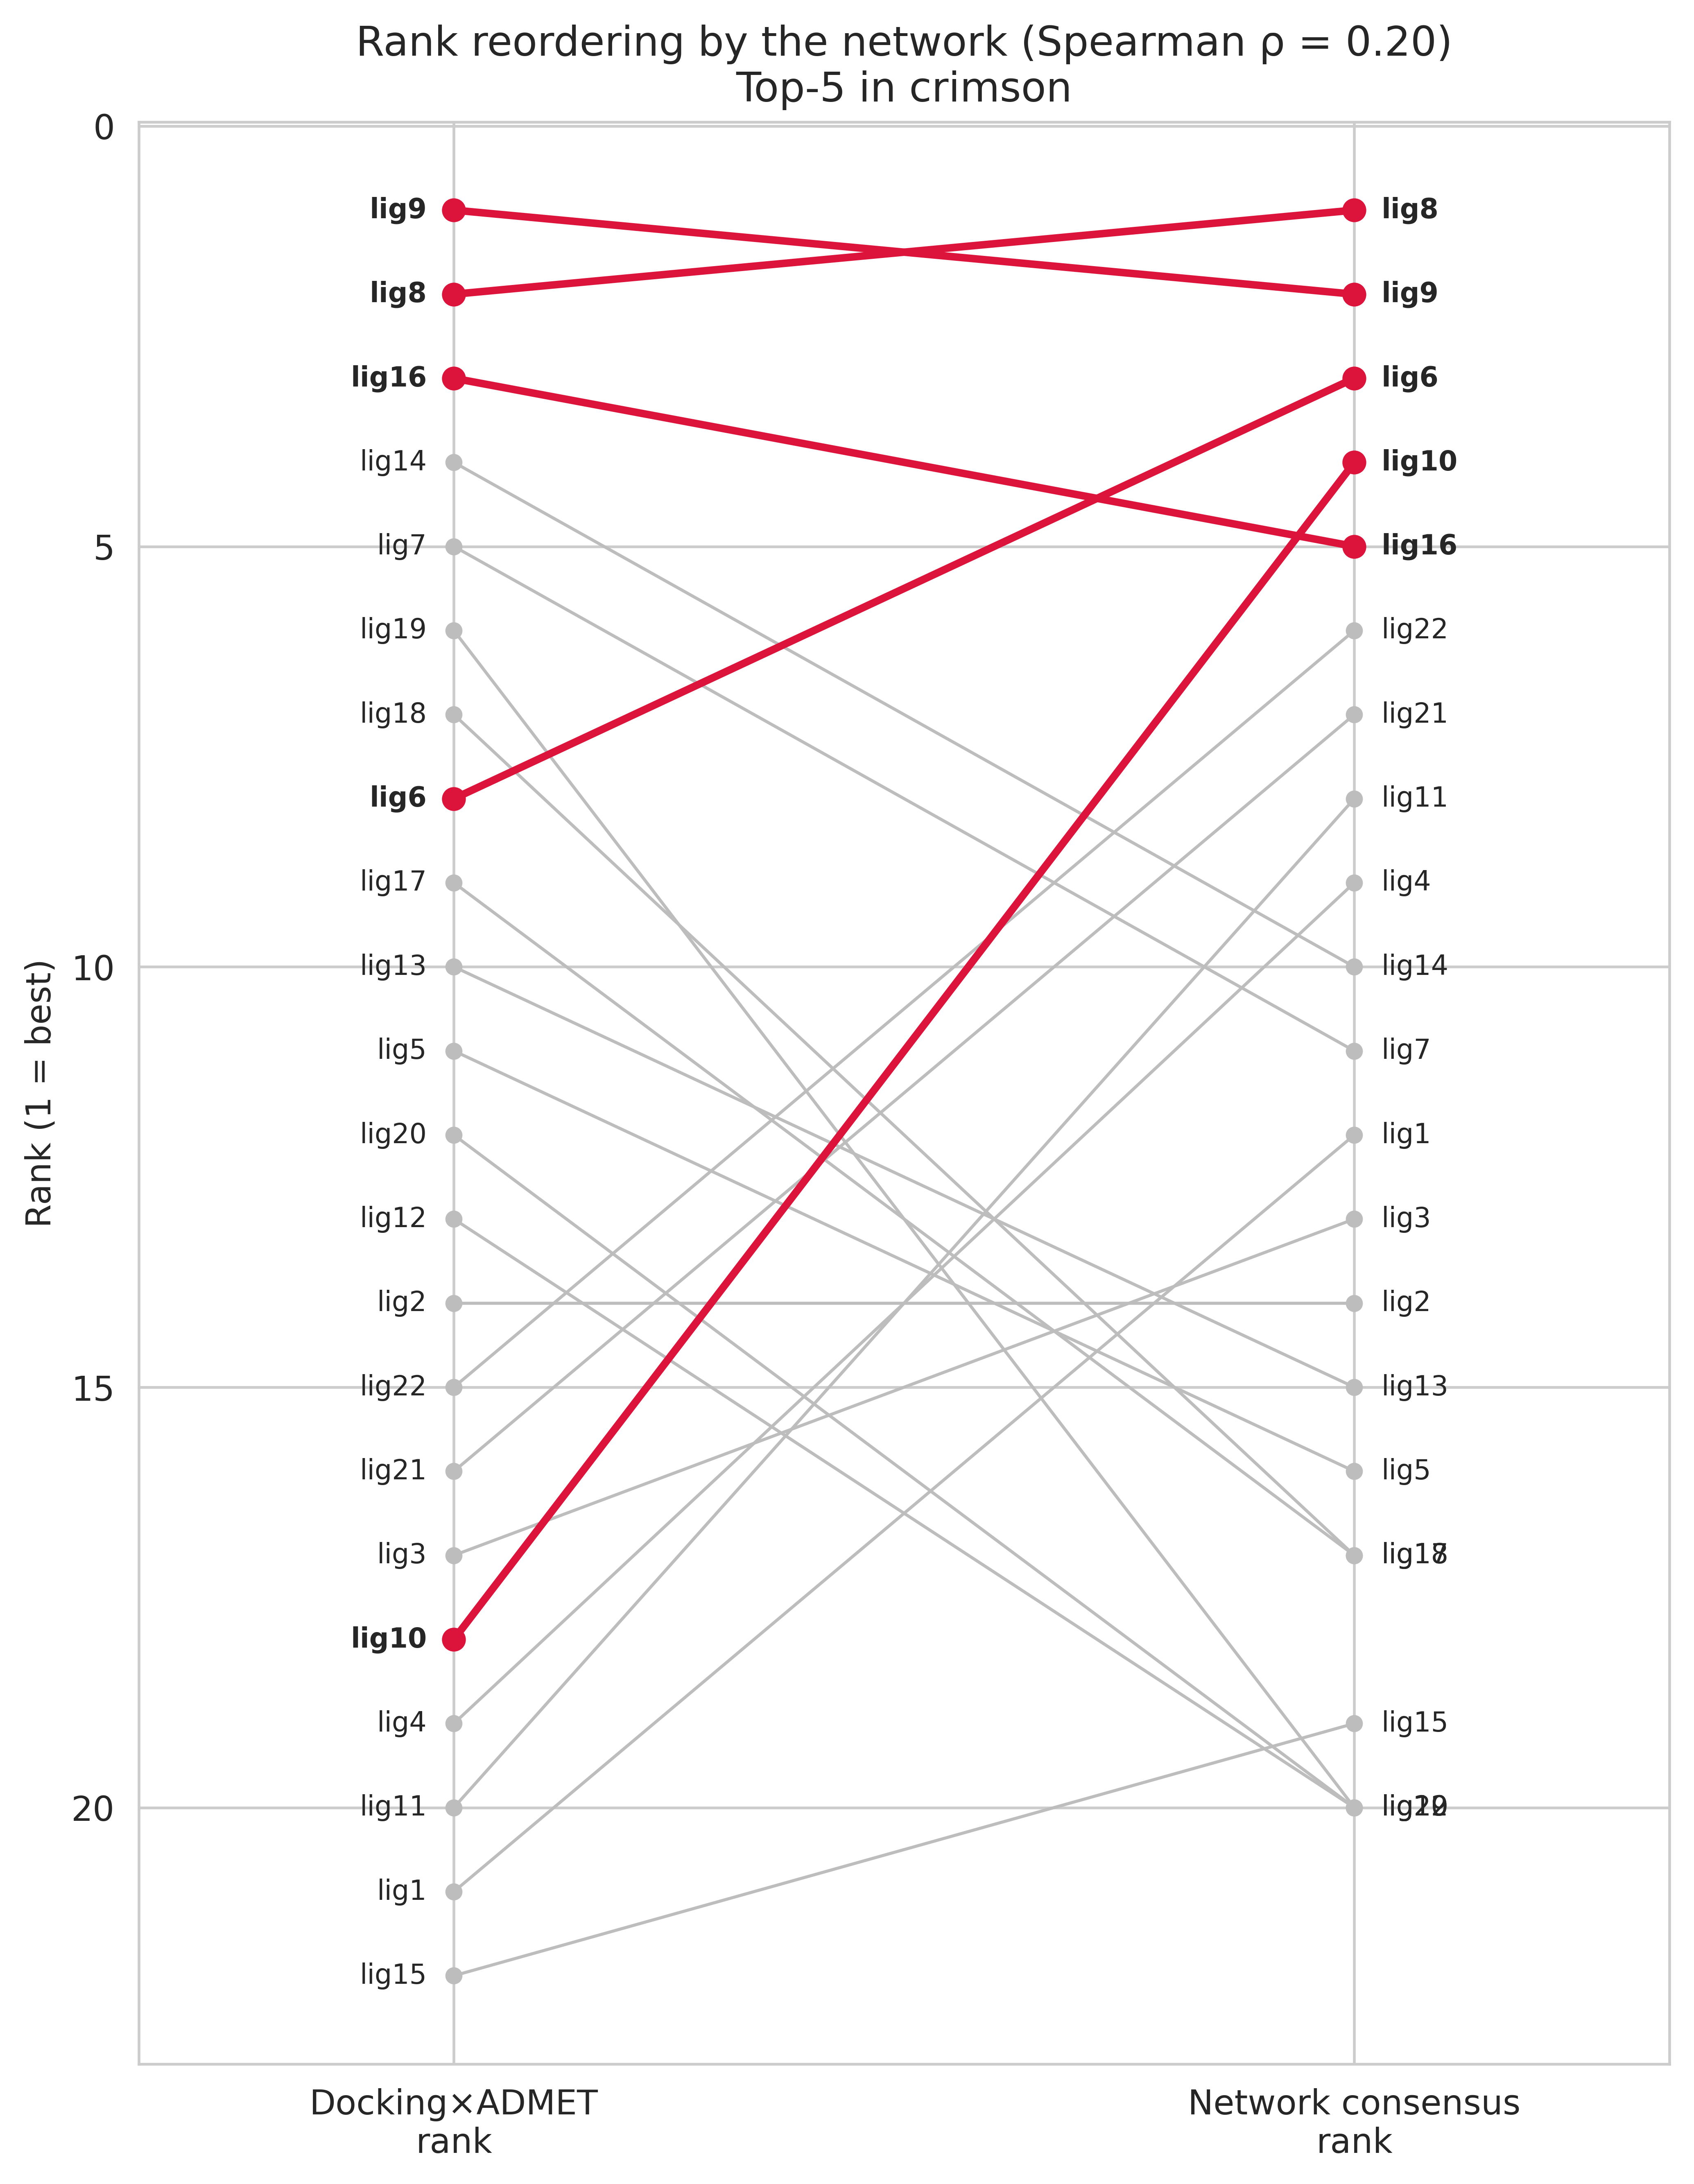

In [ ]:
# =============================================================================
# FIGURE 2 — Circularity slopegraph (docking×ADMET rank -> network rank)
# Visualizes the ρ = 0.20 reordering; top-5 highlighted
# =============================================================================
top5 = df_sorted.head(5)["node"].tolist()
rho, _ = spearmanr(merged["naive_rank"], merged["final_rank"])

plt.figure(figsize=(7, 9), dpi=300)
for _, r in merged.iterrows():
    is_top = r["node"] in top5
    plt.plot([0, 1], [r["naive_rank"], r["final_rank"]],
             color="crimson" if is_top else "#bdbdbd",
             lw=2.2 if is_top else 0.9, marker="o", markersize=6 if is_top else 4,
             zorder=3 if is_top else 1)
    plt.text(-0.03, r["naive_rank"], r["node"], ha="right", va="center",
             fontsize=8, fontweight="bold" if is_top else "normal")
    plt.text(1.03, r["final_rank"], r["node"], ha="left", va="center",
             fontsize=8, fontweight="bold" if is_top else "normal")
plt.gca().invert_yaxis()
plt.xlim(-0.35, 1.35); plt.xticks([0, 1], ["Docking×ADMET\nrank", "Network consensus\nrank"])
plt.ylabel("Rank (1 = best)")
plt.title(f"Rank reordering by the network (Spearman ρ = {rho:.2f})\n"
          "Top-5 in crimson", fontsize=12)
plt.tight_layout()
plt.savefig("fig_circularity_slopegraph.png", dpi=300, bbox_inches="tight")
plt.show()

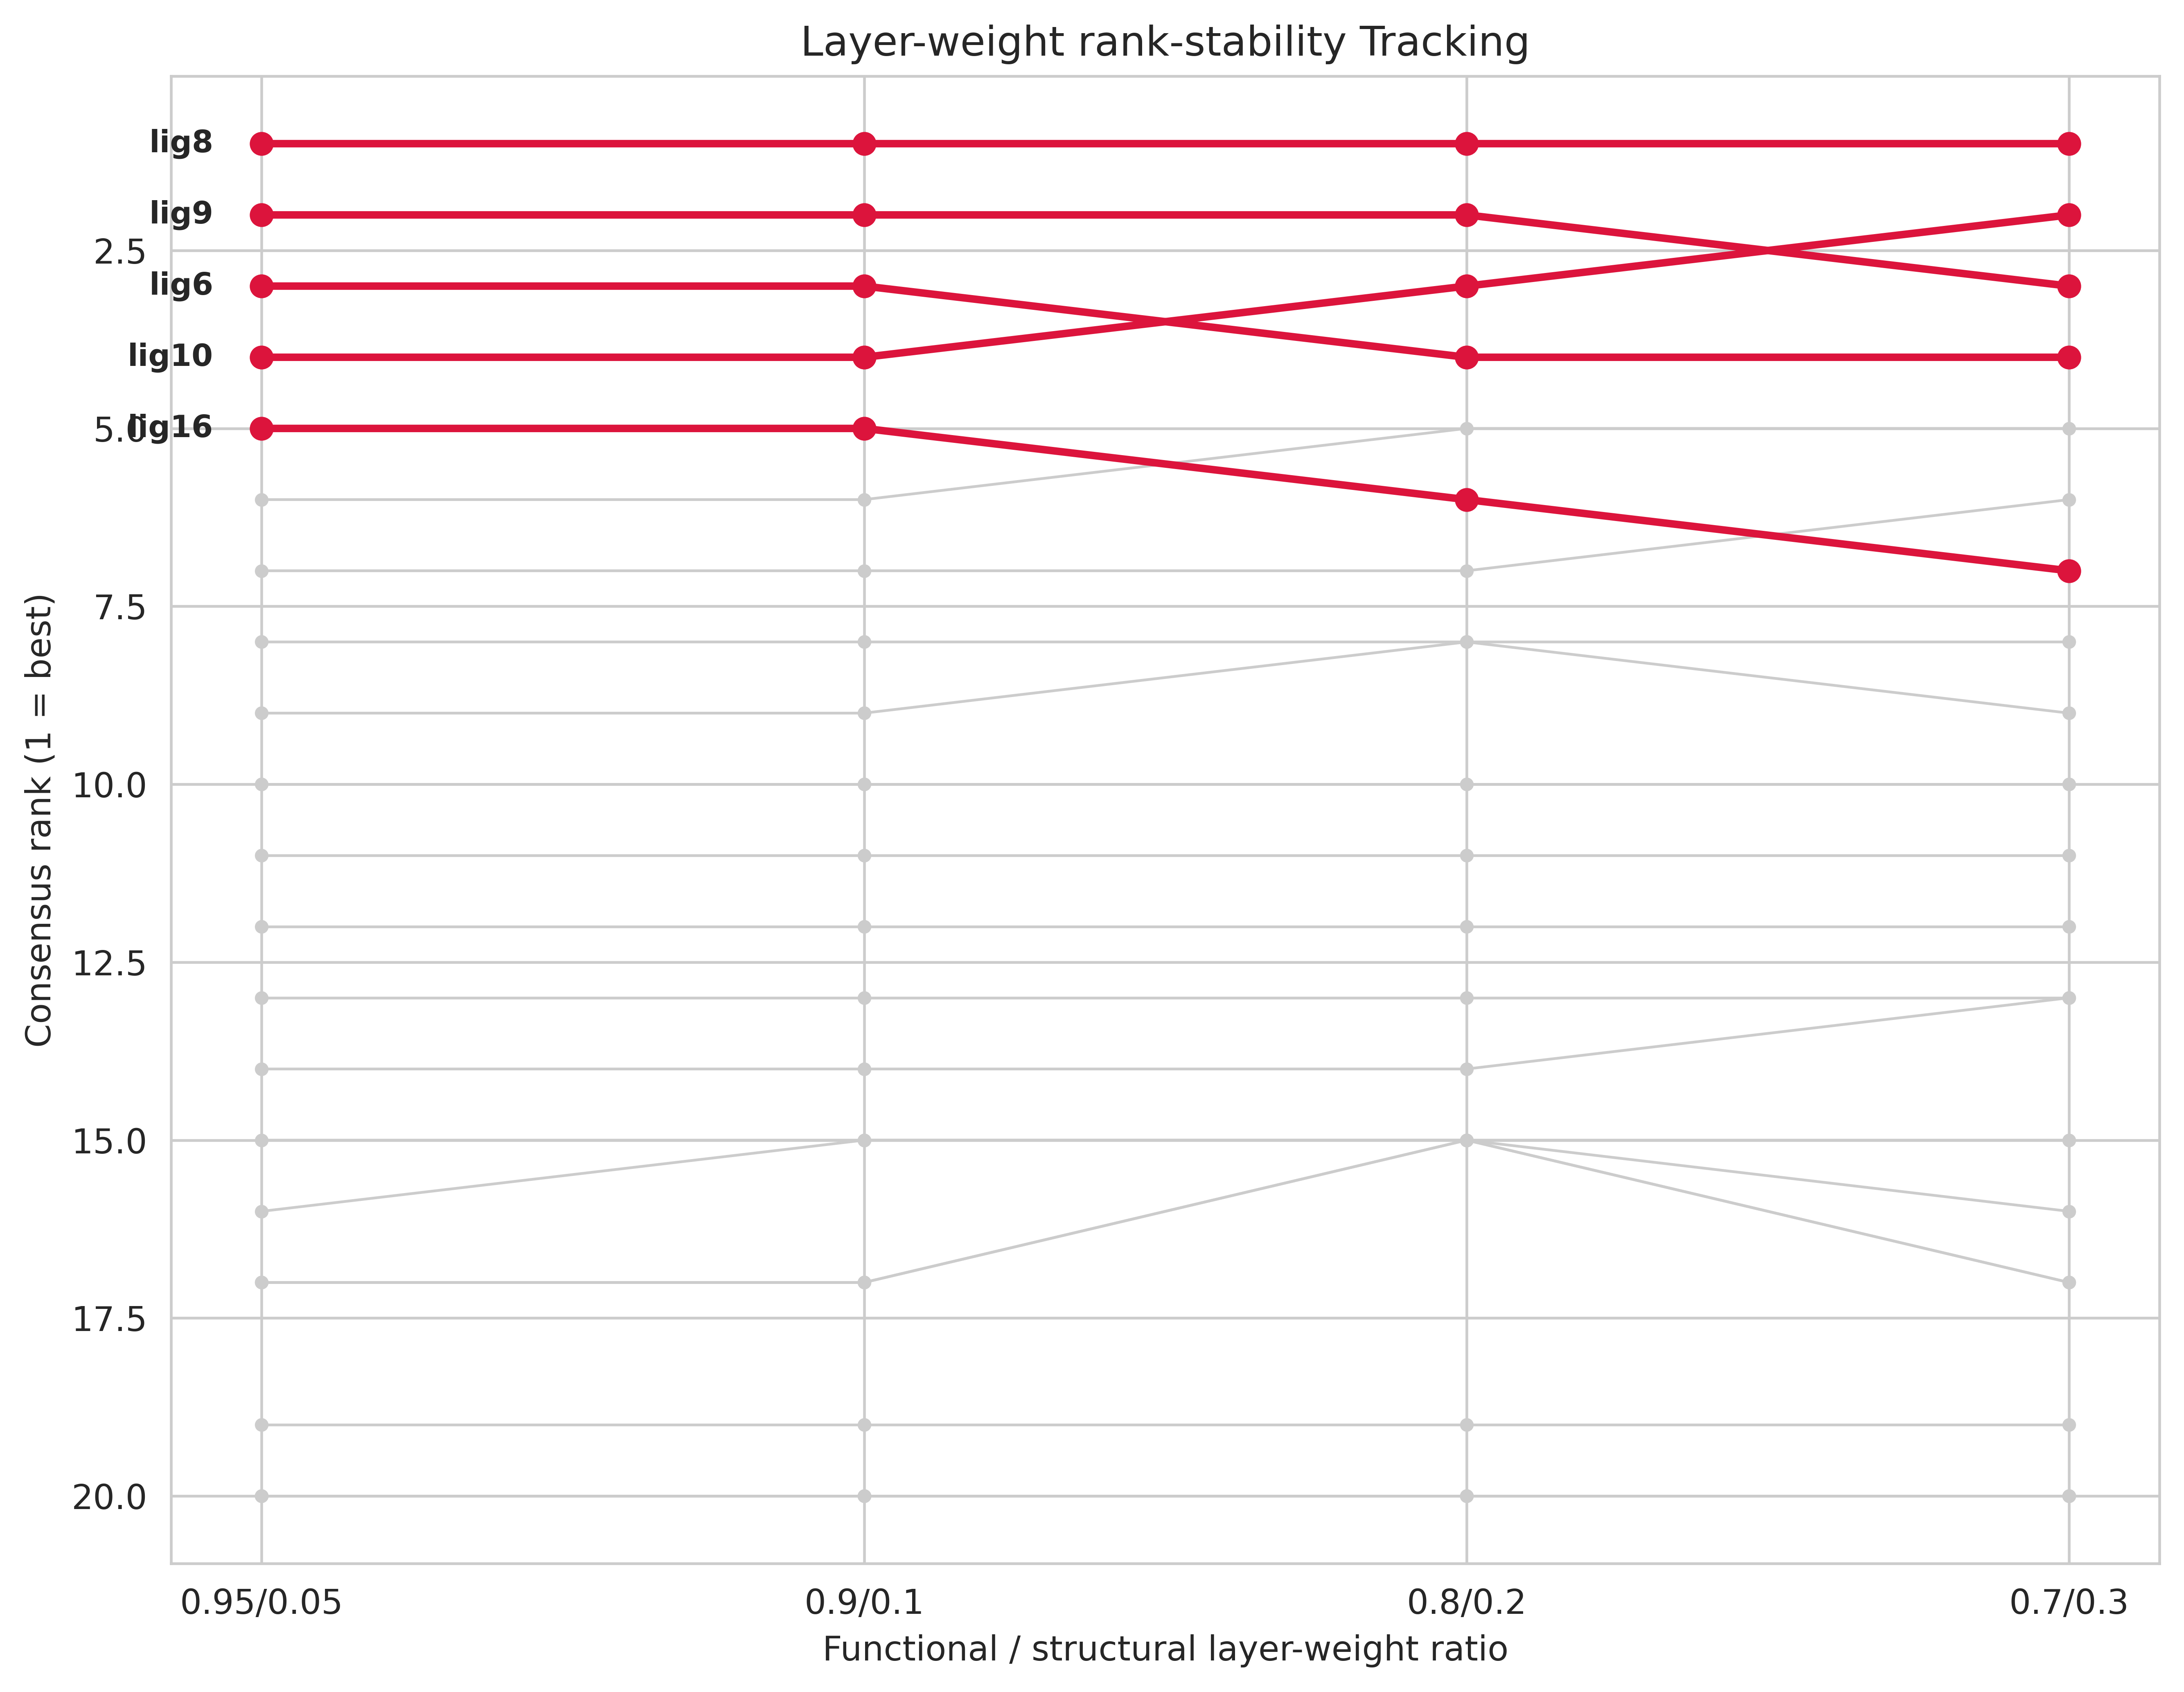

In [ ]:
# =============================================================================
# FIGURE 3 — Layer-weight rank-stability tracking
# Each line = one ligand's consensus rank across functional/structural ratios.
# Flat top-5 lines = stable prioritization (your ρ ≥ 0.99 result, made visual).
# =============================================================================
grid = [(0.95, 0.05), (0.90, 0.10), (0.80, 0.20), (0.70, 0.30)]
rank_track = {}
for fw, sw in grid:
    G_lw = build_graph({"docking_admet": fw, "similarity": sw})
    rank_track[f"{fw}/{sw}"] = compute_consensus_scores(G_lw).set_index("node")["final_rank"]
rank_df = pd.DataFrame(rank_track)

plt.figure(figsize=(9, 7), dpi=300)
for lig in rank_df.index:
    is_top = lig in top5
    plt.plot(range(len(grid)), rank_df.loc[lig].values,
             color="crimson" if is_top else "#cccccc",
             lw=2.2 if is_top else 0.8, marker="o", markersize=6 if is_top else 3,
             label=lig if is_top else None, zorder=3 if is_top else 1)
    if is_top:
        plt.text(-0.08, rank_df.loc[lig].values[0], lig, ha="right", va="center",
                 fontsize=9, fontweight="bold")
plt.gca().invert_yaxis()
plt.xticks(range(len(grid)), [f"{fw}/{sw}" for fw, sw in grid])
plt.xlabel("Functional / structural layer-weight ratio"); plt.ylabel("Consensus rank (1 = best)")
plt.title("Layer-weight rank-stability Tracking", fontsize=12)
plt.tight_layout()
plt.savefig("fig_layerweight_stability.png", dpi=300, bbox_inches="tight")
plt.show()

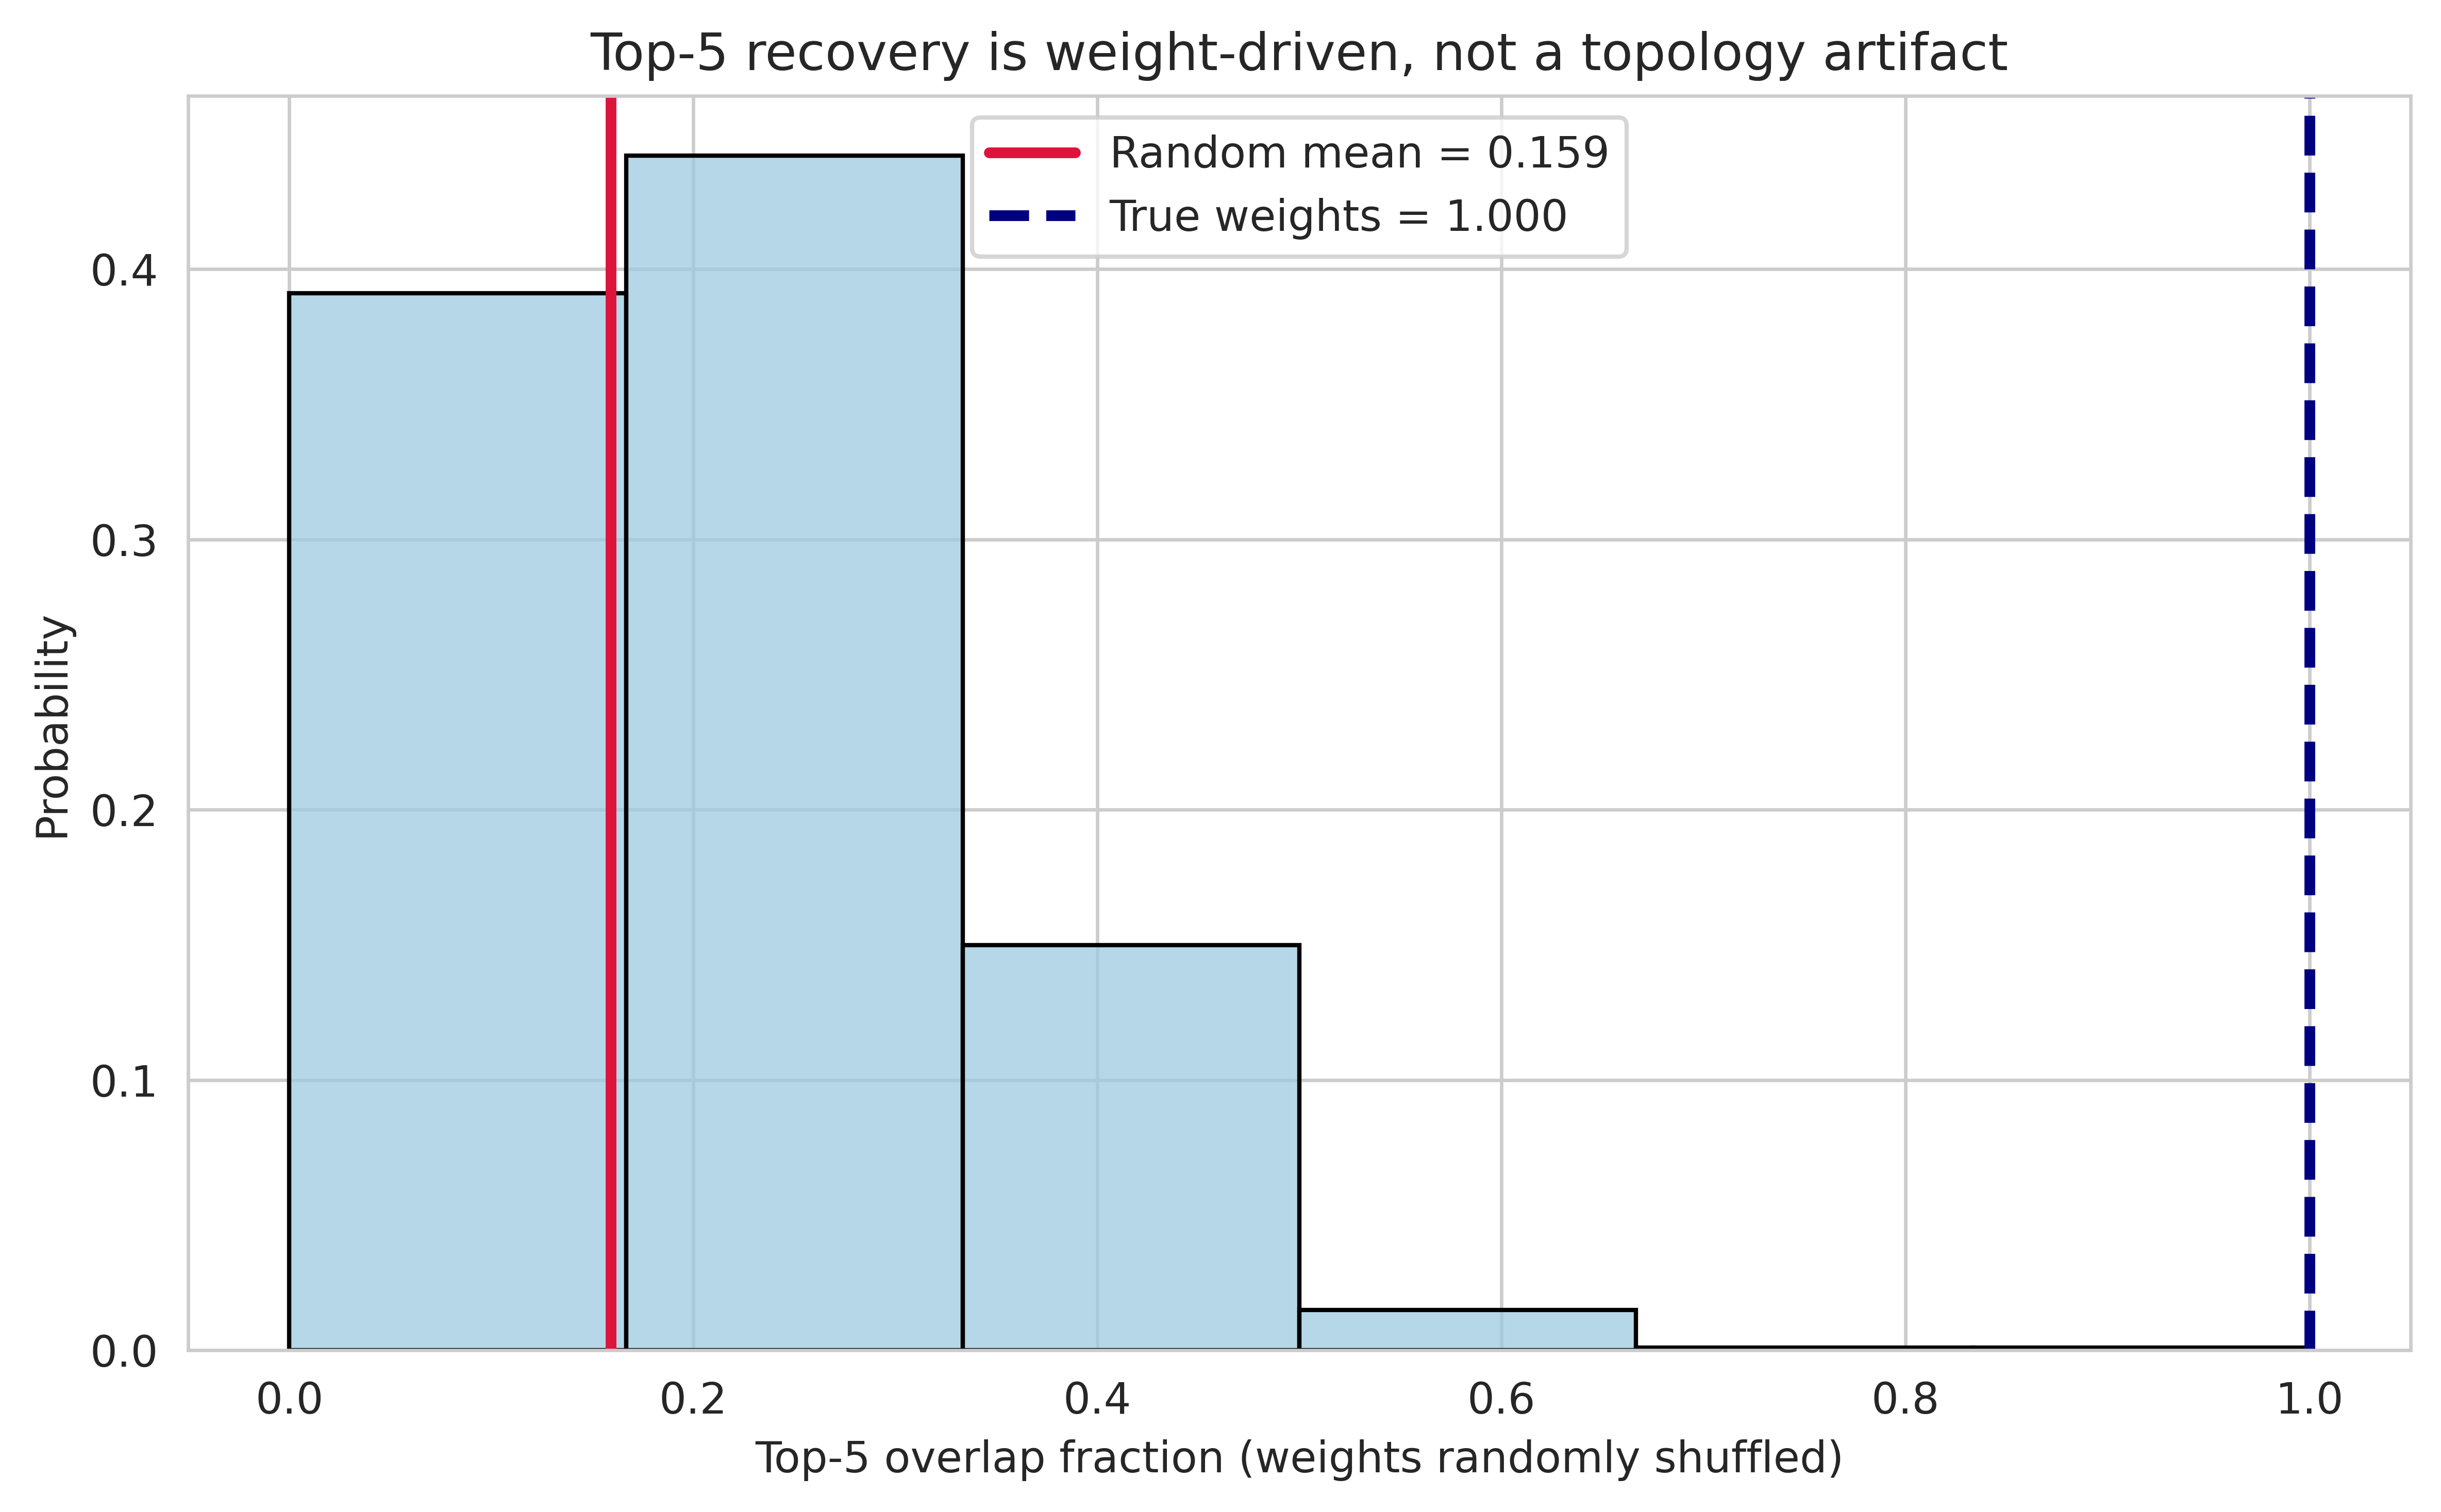

In [ ]:
# =============================================================================
# FIGURE 4 — Edge-weight shuffle null distribution
# Random top-5 recovery (gray) vs perfect recovery under true weights (navy).
# =============================================================================
plt.figure(figsize=(8, 5), dpi=300)
sns.histplot(overlaps, bins=6, color="#9ecae1", edgecolor="black", stat="probability")
plt.axvline(overlaps.mean(), color="crimson", lw=2.5,
            label=f"Random mean = {overlaps.mean():.3f}")
plt.axvline(1.0, color="navy", lw=2.5, ls="--", label="True weights = 1.000")
plt.xlabel("Top-5 overlap fraction (weights randomly shuffled)")
plt.ylabel("Probability")
plt.title("Top-5 recovery is weight-driven, not a topology artifact", fontsize=12)
plt.legend()
plt.tight_layout()
plt.savefig("fig_weightshuffle_null.png", dpi=300, bbox_inches="tight")
plt.show()


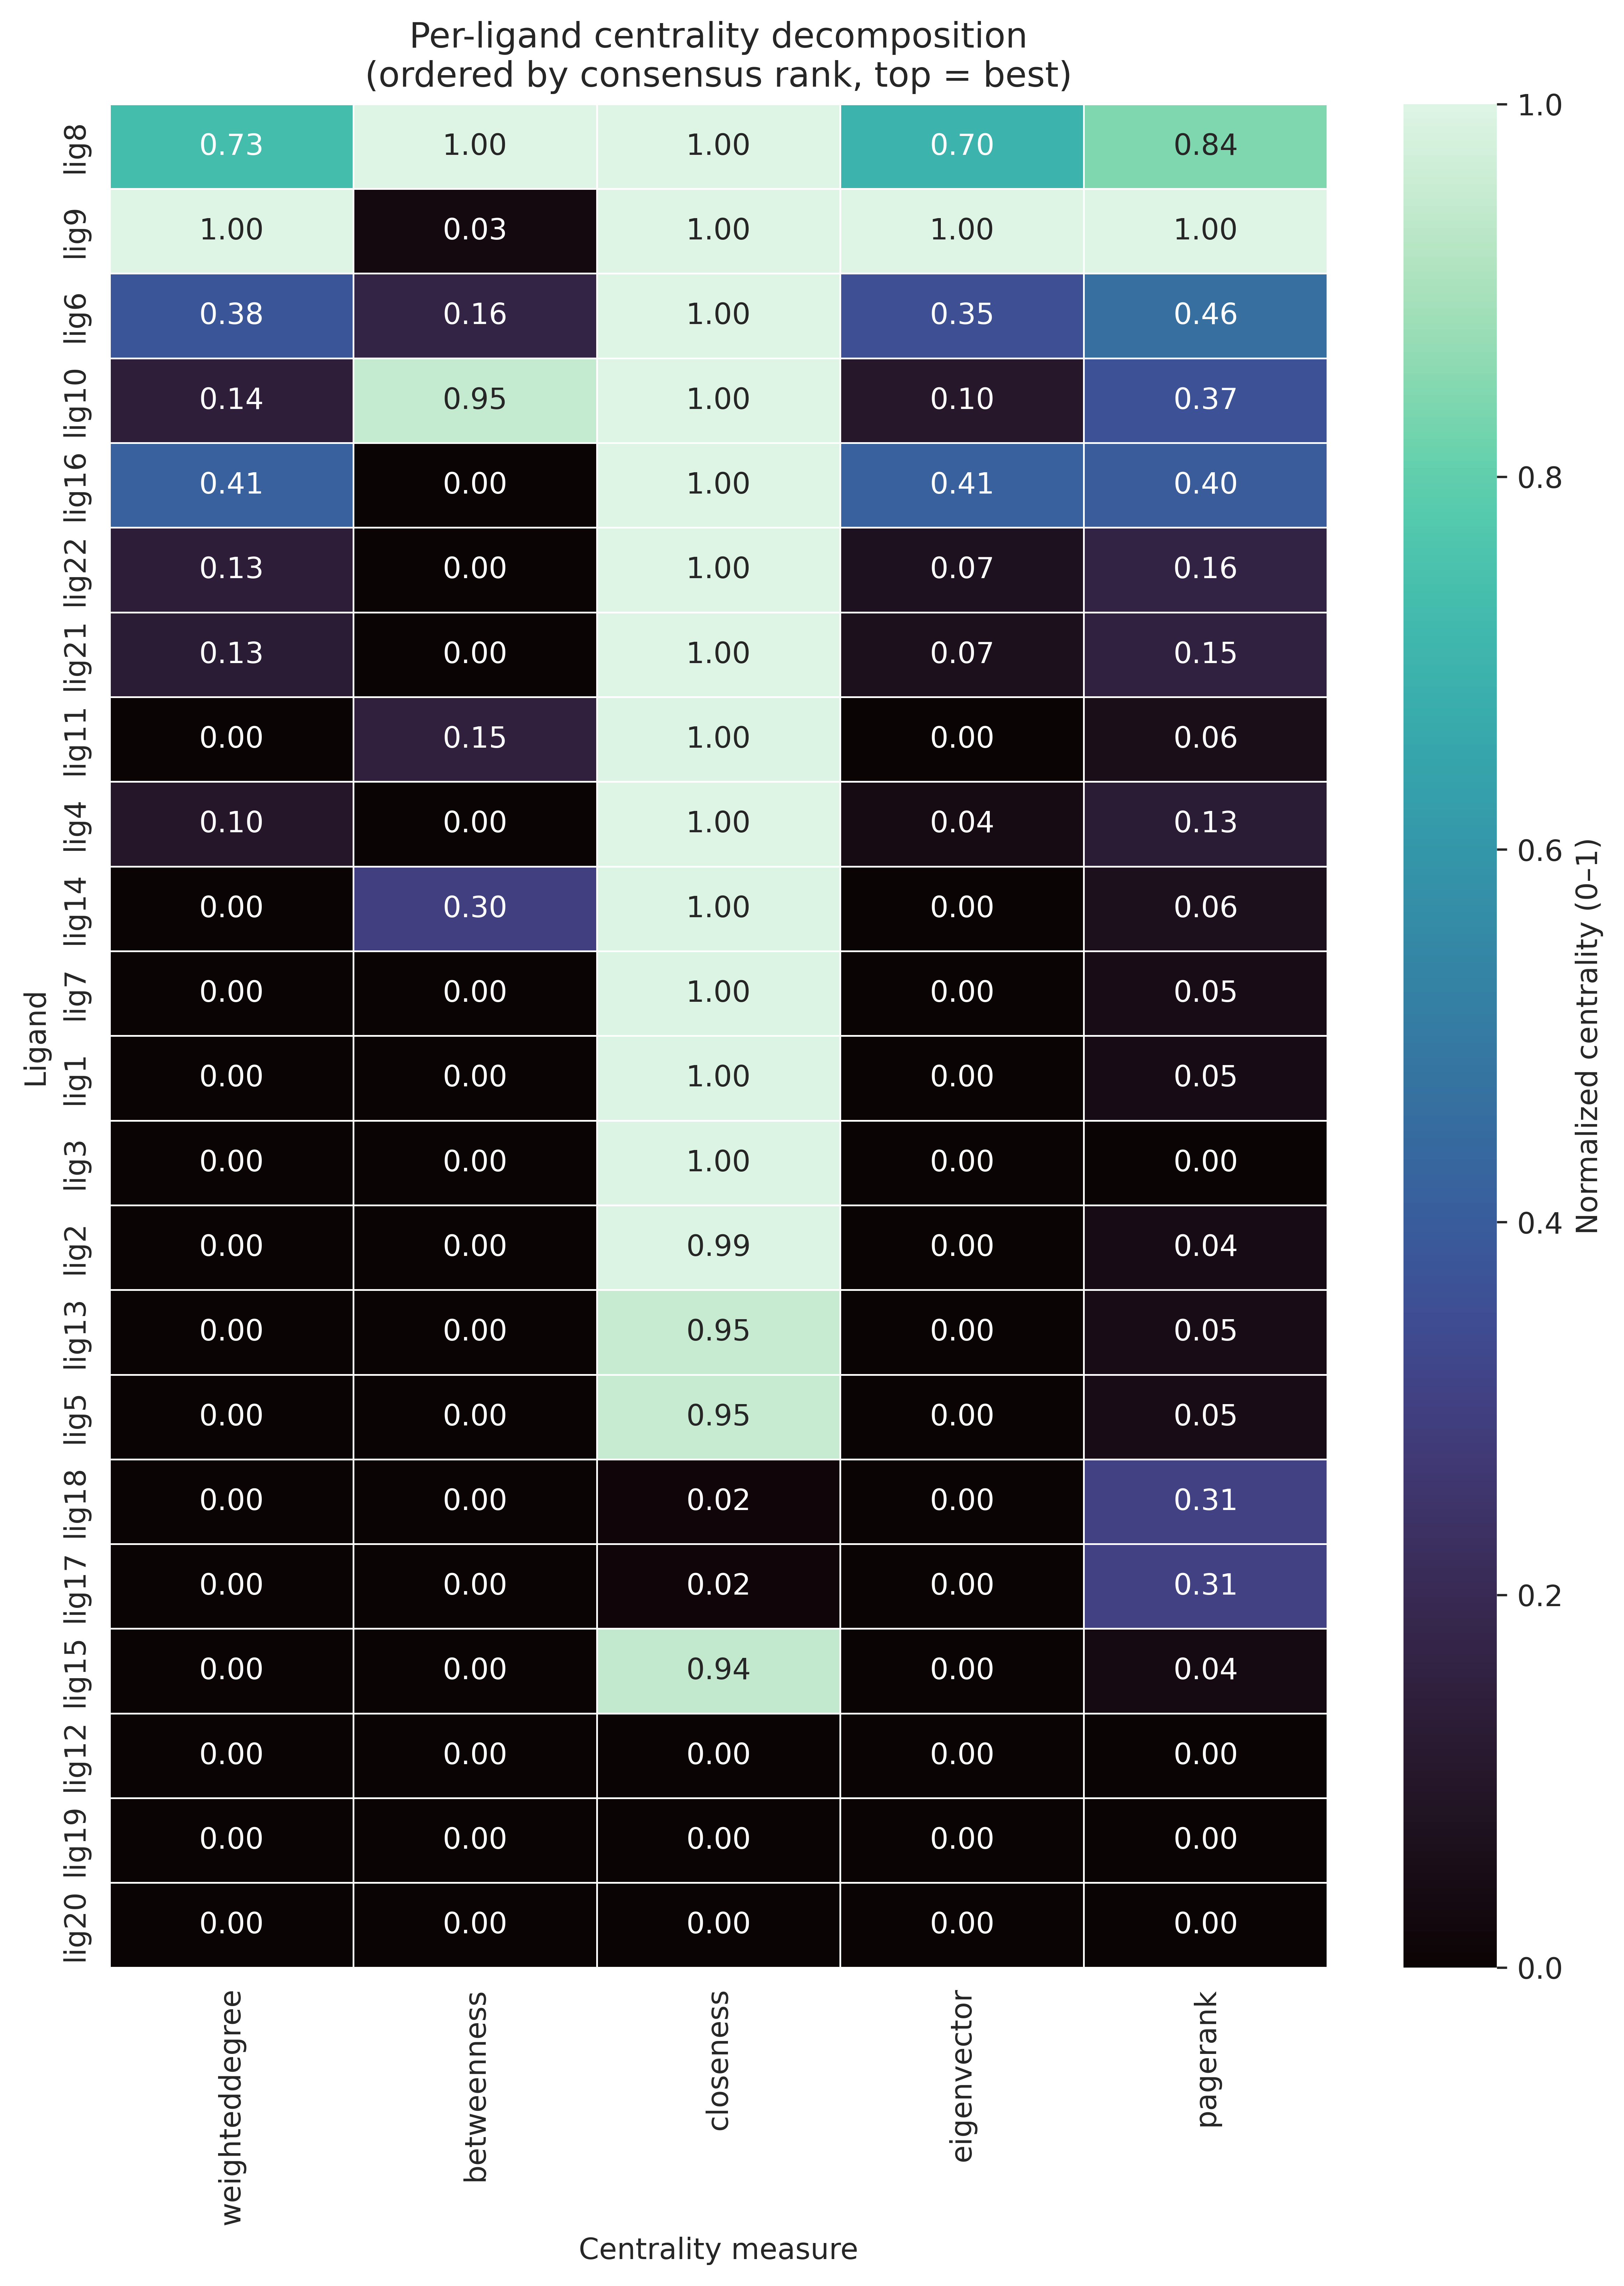

In [ ]:
# =============================================================================
# FIGURE 5 — Per-candidate centrality decomposition heatmap
# Shows WHICH centralities drive each ligand's rank (binding- vs neighborhood-
# driven). Rows ordered by consensus.
# =============================================================================
full = compute_consensus_scores(G)   # full df, already sorted by consensus
cent_cols = ["weighteddegree", "betweenness", "closeness", "eigenvector", "pagerank"]
hm = full.set_index("node")[cent_cols]

plt.figure(figsize=(8, 11), dpi=300)
sns.heatmap(hm, annot=True, fmt=".2f", cmap="mako",
            cbar_kws={"label": "Normalized centrality (0–1)"}, linewidths=0.4)
plt.title("Per-ligand centrality decomposition\n(ordered by consensus rank, top = best)",
          fontsize=12)
plt.xlabel("Centrality measure"); plt.ylabel("Ligand")
plt.tight_layout()
plt.savefig("fig_centrality_decomposition.png", dpi=300, bbox_inches="tight")
plt.show()